### Formula 1 Race Strategy & Tyre Performance Analysis

I choose 2024 Hungarian GP because it provides a clean, professional strategy-analysis story without weather randomness dominating the results.

In [1]:
# Pit Stop Strategy Comparison
import pandas as pd

In [2]:
url = "https://www.formula1.com/en/results/2024/races/1241/hungary/pit-stop-summary"

tables = pd.read_html(url)

print(len(tables))

1


In [3]:
tables

[    Stops  No.               Driver                          Team  Lap  \
 0       1   27   Nico HulkenbergHUL                  Haas Ferrari    2   
 1       1   20   Kevin MagnussenMAG                  Haas Ferrari    6   
 2       1   23   Alexander AlbonALB             Williams Mercedes    6   
 3       1   31      Esteban OconOCO                Alpine Renault    6   
 4       1   14   Fernando AlonsoALO  Aston Martin Aramco Mercedes    7   
 5       1    3  Daniel RicciardoRIC                 RB Honda RBPT    7   
 6       1   24       Zhou GuanyuZHO           Kick Sauber Ferrari    7   
 7       1    2    Logan SargeantSAR             Williams Mercedes    8   
 8       1   18      Lance StrollSTR  Aston Martin Aramco Mercedes   14   
 9       1   44    Lewis HamiltonHAM                      Mercedes   16   
 10      1   77   Valtteri BottasBOT           Kick Sauber Ferrari   16   
 11      1    4      Lando NorrisNOR              McLaren Mercedes   17   
 12      1   81     Oscar

In [4]:
# converting tables into dataframe
pitstop = tables[0]
pitstop

,Stops,No.,Driver,Team,Lap,Time of Day,Time,Total
0,1,27,Nico HulkenbergHUL,Haas Ferrari,2,15:06:01,22.287,22.287
1,1,20,Kevin MagnussenMAG,Haas Ferrari,6,15:11:43,21.871,21.871
2,1,23,Alexander AlbonALB,Williams Mercedes,6,15:11:43,22.091,22.091
3,1,31,Esteban OconOCO,Alpine Renault,6,15:11:47,21.829,21.829
4,1,14,Fernando AlonsoALO,Aston Martin Aramco Mercedes,7,15:13:05,22.542,22.542
5,1,3,Daniel RicciardoRIC,RB Honda RBPT,7,15:13:08,21.084,21.084
6,1,24,Zhou GuanyuZHO,Kick Sauber Ferrari,7,15:13:15,21.993,21.993
7,1,2,Logan SargeantSAR,Williams Mercedes,8,15:14:38,21.757,21.757
8,1,18,Lance StrollSTR,Aston Martin Aramco Mercedes,14,15:23:01,23.237,23.237
9,1,44,Lewis HamiltonHAM,Mercedes,16,15:25:36,21.306,21.306


In [5]:
pitstop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Stops        40 non-null     int64  
 1   No.          40 non-null     int64  
 2   Driver       40 non-null     object 
 3   Team         40 non-null     object 
 4   Lap          40 non-null     int64  
 5   Time of Day  40 non-null     object 
 6   Time         40 non-null     float64
 7   Total        40 non-null     object 
dtypes: float64(1), int64(3), object(4)
memory usage: 2.6+ KB


In [6]:
# convert total to time in seconds
def time_to_seconds(x):
  x = str(x)
  if ':' in x:
    min, sec = x.split(':')
    return float(min) * 60 + float(sec)
  return float(x)

pitstop['Pit Time (sec)'] = pitstop['Time'].apply(time_to_seconds)
pitstop['Total Pit Time (sec)'] = pitstop['Total'].apply(time_to_seconds)
pitstop

,Stops,No.,Driver,Team,Lap,Time of Day,Time,Total,Pit Time (sec),Total Pit Time (sec)
0,1,27,Nico HulkenbergHUL,Haas Ferrari,2,15:06:01,22.287,22.287,22.287,22.287
1,1,20,Kevin MagnussenMAG,Haas Ferrari,6,15:11:43,21.871,21.871,21.871,21.871
2,1,23,Alexander AlbonALB,Williams Mercedes,6,15:11:43,22.091,22.091,22.091,22.091
3,1,31,Esteban OconOCO,Alpine Renault,6,15:11:47,21.829,21.829,21.829,21.829
4,1,14,Fernando AlonsoALO,Aston Martin Aramco Mercedes,7,15:13:05,22.542,22.542,22.542,22.542
5,1,3,Daniel RicciardoRIC,RB Honda RBPT,7,15:13:08,21.084,21.084,21.084,21.084
6,1,24,Zhou GuanyuZHO,Kick Sauber Ferrari,7,15:13:15,21.993,21.993,21.993,21.993
7,1,2,Logan SargeantSAR,Williams Mercedes,8,15:14:38,21.757,21.757,21.757,21.757
8,1,18,Lance StrollSTR,Aston Martin Aramco Mercedes,14,15:23:01,23.237,23.237,23.237,23.237
9,1,44,Lewis HamiltonHAM,Mercedes,16,15:25:36,21.306,21.306,21.306,21.306


In [7]:
pitstop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Stops                 40 non-null     int64  
 1   No.                   40 non-null     int64  
 2   Driver                40 non-null     object 
 3   Team                  40 non-null     object 
 4   Lap                   40 non-null     int64  
 5   Time of Day           40 non-null     object 
 6   Time                  40 non-null     float64
 7   Total                 40 non-null     object 
 8   Pit Time (sec)        40 non-null     float64
 9   Total Pit Time (sec)  40 non-null     float64
dtypes: float64(3), int64(3), object(4)
memory usage: 3.3+ KB


In [8]:
# changing it into proper format
pit = pitstop[[
    'No.', 'Driver', 'Team', 'Stops', 'Lap', 'Pit Time (sec)', 'Total Pit Time (sec)'
]]
pit

,No.,Driver,Team,Stops,Lap,Pit Time (sec),Total Pit Time (sec)
0,27,Nico HulkenbergHUL,Haas Ferrari,1,2,22.287,22.287
1,20,Kevin MagnussenMAG,Haas Ferrari,1,6,21.871,21.871
2,23,Alexander AlbonALB,Williams Mercedes,1,6,22.091,22.091
3,31,Esteban OconOCO,Alpine Renault,1,6,21.829,21.829
4,14,Fernando AlonsoALO,Aston Martin Aramco Mercedes,1,7,22.542,22.542
5,3,Daniel RicciardoRIC,RB Honda RBPT,1,7,21.084,21.084
6,24,Zhou GuanyuZHO,Kick Sauber Ferrari,1,7,21.993,21.993
7,2,Logan SargeantSAR,Williams Mercedes,1,8,21.757,21.757
8,18,Lance StrollSTR,Aston Martin Aramco Mercedes,1,14,23.237,23.237
9,44,Lewis HamiltonHAM,Mercedes,1,16,21.306,21.306


In [9]:
# separate driver name and abbreviation
pit = pit.copy()
pit[['Driver', 'Abbreviation']] = pit['Driver'].str.extract(r'(.+?)([A-Z]{3})$')
pit

,No.,Driver,Team,Stops,Lap,Pit Time (sec),Total Pit Time (sec),Abbreviation
0,27,Nico Hulkenberg,Haas Ferrari,1,2,22.287,22.287,HUL
1,20,Kevin Magnussen,Haas Ferrari,1,6,21.871,21.871,MAG
2,23,Alexander Albon,Williams Mercedes,1,6,22.091,22.091,ALB
3,31,Esteban Ocon,Alpine Renault,1,6,21.829,21.829,OCO
4,14,Fernando Alonso,Aston Martin Aramco Mercedes,1,7,22.542,22.542,ALO
5,3,Daniel Ricciardo,RB Honda RBPT,1,7,21.084,21.084,RIC
6,24,Zhou Guanyu,Kick Sauber Ferrari,1,7,21.993,21.993,ZHO
7,2,Logan Sargeant,Williams Mercedes,1,8,21.757,21.757,SAR
8,18,Lance Stroll,Aston Martin Aramco Mercedes,1,14,23.237,23.237,STR
9,44,Lewis Hamilton,Mercedes,1,16,21.306,21.306,HAM


In [10]:
# rename abbreviation to driver and remove driver
pit = pit[[
    'No.', 'Abbreviation', 'Team', 'Stops', 'Lap', 'Pit Time (sec)', 'Total Pit Time (sec)'
]]
pit = pit.rename(columns = {'Abbreviation': 'Driver'})
pit

,No.,Driver,Team,Stops,Lap,Pit Time (sec),Total Pit Time (sec)
0,27,HUL,Haas Ferrari,1,2,22.287,22.287
1,20,MAG,Haas Ferrari,1,6,21.871,21.871
2,23,ALB,Williams Mercedes,1,6,22.091,22.091
3,31,OCO,Alpine Renault,1,6,21.829,21.829
4,14,ALO,Aston Martin Aramco Mercedes,1,7,22.542,22.542
5,3,RIC,RB Honda RBPT,1,7,21.084,21.084
6,24,ZHO,Kick Sauber Ferrari,1,7,21.993,21.993
7,2,SAR,Williams Mercedes,1,8,21.757,21.757
8,18,STR,Aston Martin Aramco Mercedes,1,14,23.237,23.237
9,44,HAM,Mercedes,1,16,21.306,21.306


In [11]:
pit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   No.                   40 non-null     int64  
 1   Driver                40 non-null     object 
 2   Team                  40 non-null     object 
 3   Stops                 40 non-null     int64  
 4   Lap                   40 non-null     int64  
 5   Pit Time (sec)        40 non-null     float64
 6   Total Pit Time (sec)  40 non-null     float64
dtypes: float64(2), int64(3), object(2)
memory usage: 2.3+ KB


In [12]:
# pivot for laps
lap_pivot = pit.pivot_table(
    index=['No.', 'Driver', 'Team'],
    columns='Stops',
    values='Lap'
)
lap_pivot

,,Stops,1,2,3
No.,Driver,Team,,,
1,VER,Red Bull Racing Honda RBPT,21.0,49.0,NaN
2,SAR,Williams Mercedes,8.0,33.0,63.0
3,RIC,RB Honda RBPT,7.0,28.0,NaN
4,NOR,McLaren Mercedes,17.0,45.0,NaN
10,GAS,Alpine Renault,28.0,NaN,NaN
11,PER,Red Bull Racing Honda RBPT,28.0,47.0,NaN
14,ALO,Aston Martin Aramco Mercedes,7.0,37.0,NaN
16,LEC,Ferrari,23.0,40.0,NaN
18,STR,Aston Martin Aramco Mercedes,14.0,45.0,NaN


In [13]:

# pivot for time
time_pivot = pit.pivot_table(
    index=['No.', 'Driver', 'Team'],
    columns='Stops',
    values='Pit Time (sec)'
)
time_pivot

,,Stops,1,2,3
No.,Driver,Team,,,
1,VER,Red Bull Racing Honda RBPT,22.101,21.344,NaN
2,SAR,Williams Mercedes,21.757,21.398,21.908
3,RIC,RB Honda RBPT,21.084,21.378,NaN
4,NOR,McLaren Mercedes,21.861,21.249,NaN
10,GAS,Alpine Renault,21.405,NaN,NaN
11,PER,Red Bull Racing Honda RBPT,21.395,21.056,NaN
14,ALO,Aston Martin Aramco Mercedes,22.542,21.800,NaN
16,LEC,Ferrari,21.894,21.723,NaN
18,STR,Aston Martin Aramco Mercedes,23.237,22.276,NaN


In [14]:
lap_pivot.columns = ['Pit 1 Lap', 'Pit 2 Lap', 'Pit 3 Lap']
lap_pivot

,,,Pit 1 Lap,Pit 2 Lap,Pit 3 Lap
No.,Driver,Team,,,
1,VER,Red Bull Racing Honda RBPT,21.0,49.0,NaN
2,SAR,Williams Mercedes,8.0,33.0,63.0
3,RIC,RB Honda RBPT,7.0,28.0,NaN
4,NOR,McLaren Mercedes,17.0,45.0,NaN
10,GAS,Alpine Renault,28.0,NaN,NaN
11,PER,Red Bull Racing Honda RBPT,28.0,47.0,NaN
14,ALO,Aston Martin Aramco Mercedes,7.0,37.0,NaN
16,LEC,Ferrari,23.0,40.0,NaN
18,STR,Aston Martin Aramco Mercedes,14.0,45.0,NaN


In [15]:
time_pivot.columns = ['Pit 1 time', 'Pit 2 time', 'Pit 3 time']
time_pivot

,,,Pit 1 time,Pit 2 time,Pit 3 time
No.,Driver,Team,,,
1,VER,Red Bull Racing Honda RBPT,22.101,21.344,NaN
2,SAR,Williams Mercedes,21.757,21.398,21.908
3,RIC,RB Honda RBPT,21.084,21.378,NaN
4,NOR,McLaren Mercedes,21.861,21.249,NaN
10,GAS,Alpine Renault,21.405,NaN,NaN
11,PER,Red Bull Racing Honda RBPT,21.395,21.056,NaN
14,ALO,Aston Martin Aramco Mercedes,22.542,21.800,NaN
16,LEC,Ferrari,21.894,21.723,NaN
18,STR,Aston Martin Aramco Mercedes,23.237,22.276,NaN


In [16]:
# combine them
result = pd.concat([lap_pivot, time_pivot], axis = 1)
result

,,,Pit 1 Lap,Pit 2 Lap,Pit 3 Lap,Pit 1 time,Pit 2 time,Pit 3 time
No.,Driver,Team,,,,,,
1,VER,Red Bull Racing Honda RBPT,21.0,49.0,NaN,22.101,21.344,NaN
2,SAR,Williams Mercedes,8.0,33.0,63.0,21.757,21.398,21.908
3,RIC,RB Honda RBPT,7.0,28.0,NaN,21.084,21.378,NaN
4,NOR,McLaren Mercedes,17.0,45.0,NaN,21.861,21.249,NaN
10,GAS,Alpine Renault,28.0,NaN,NaN,21.405,NaN,NaN
11,PER,Red Bull Racing Honda RBPT,28.0,47.0,NaN,21.395,21.056,NaN
14,ALO,Aston Martin Aramco Mercedes,7.0,37.0,NaN,22.542,21.800,NaN
16,LEC,Ferrari,23.0,40.0,NaN,21.894,21.723,NaN
18,STR,Aston Martin Aramco Mercedes,14.0,45.0,NaN,23.237,22.276,NaN


In [17]:
# reset index
result.reset_index(inplace = True)
result

,No.,Driver,Team,Pit 1 Lap,Pit 2 Lap,Pit 3 Lap,Pit 1 time,Pit 2 time,Pit 3 time
0,1,VER,Red Bull Racing Honda RBPT,21.0,49.0,NaN,22.101,21.344,NaN
1,2,SAR,Williams Mercedes,8.0,33.0,63.0,21.757,21.398,21.908
2,3,RIC,RB Honda RBPT,7.0,28.0,NaN,21.084,21.378,NaN
3,4,NOR,McLaren Mercedes,17.0,45.0,NaN,21.861,21.249,NaN
4,10,GAS,Alpine Renault,28.0,NaN,NaN,21.405,NaN,NaN
5,11,PER,Red Bull Racing Honda RBPT,28.0,47.0,NaN,21.395,21.056,NaN
6,14,ALO,Aston Martin Aramco Mercedes,7.0,37.0,NaN,22.542,21.800,NaN
7,16,LEC,Ferrari,23.0,40.0,NaN,21.894,21.723,NaN
8,18,STR,Aston Martin Aramco Mercedes,14.0,45.0,NaN,23.237,22.276,NaN
9,20,MAG,Haas Ferrari,6.0,34.0,NaN,21.871,22.531,NaN


In [18]:
# count stops
pit_count = pit.groupby(
    ['No.', 'Driver', 'Team']
)['Stops'].max().reset_index(name = 'No. of stops')
pit_count

,No.,Driver,Team,No. of stops
0,1,VER,Red Bull Racing Honda RBPT,2
1,2,SAR,Williams Mercedes,3
2,3,RIC,RB Honda RBPT,2
3,4,NOR,McLaren Mercedes,2
4,10,GAS,Alpine Renault,1
5,11,PER,Red Bull Racing Honda RBPT,2
6,14,ALO,Aston Martin Aramco Mercedes,2
7,16,LEC,Ferrari,2
8,18,STR,Aston Martin Aramco Mercedes,2
9,20,MAG,Haas Ferrari,2


In [19]:
# add no. of stops to result
result = pd.merge(
    result,
    pit_count,
    how = 'left',
    on = ['No.', 'Driver', 'Team']
)
result

,No.,Driver,Team,Pit 1 Lap,Pit 2 Lap,Pit 3 Lap,Pit 1 time,Pit 2 time,Pit 3 time,No. of stops
0,1,VER,Red Bull Racing Honda RBPT,21.0,49.0,NaN,22.101,21.344,NaN,2
1,2,SAR,Williams Mercedes,8.0,33.0,63.0,21.757,21.398,21.908,3
2,3,RIC,RB Honda RBPT,7.0,28.0,NaN,21.084,21.378,NaN,2
3,4,NOR,McLaren Mercedes,17.0,45.0,NaN,21.861,21.249,NaN,2
4,10,GAS,Alpine Renault,28.0,NaN,NaN,21.405,NaN,NaN,1
5,11,PER,Red Bull Racing Honda RBPT,28.0,47.0,NaN,21.395,21.056,NaN,2
6,14,ALO,Aston Martin Aramco Mercedes,7.0,37.0,NaN,22.542,21.800,NaN,2
7,16,LEC,Ferrari,23.0,40.0,NaN,21.894,21.723,NaN,2
8,18,STR,Aston Martin Aramco Mercedes,14.0,45.0,NaN,23.237,22.276,NaN,2
9,20,MAG,Haas Ferrari,6.0,34.0,NaN,21.871,22.531,NaN,2


In [20]:
pit_loss = pit.groupby(
    ['No.', 'Driver', 'Team']
)['Total Pit Time (sec)'].max().reset_index(name = 'Pit Loss')
pit_loss

,No.,Driver,Team,Pit Loss
0,1,VER,Red Bull Racing Honda RBPT,43.445
1,2,SAR,Williams Mercedes,65.063
2,3,RIC,RB Honda RBPT,42.462
3,4,NOR,McLaren Mercedes,43.110
4,10,GAS,Alpine Renault,21.405
5,11,PER,Red Bull Racing Honda RBPT,42.451
6,14,ALO,Aston Martin Aramco Mercedes,44.342
7,16,LEC,Ferrari,43.617
8,18,STR,Aston Martin Aramco Mercedes,45.513
9,20,MAG,Haas Ferrari,44.402


In [21]:
# add pit loss to result
result = pd.merge(
    result,
    pit_loss,
    how = 'left',
    on = ['No.', 'Driver', 'Team']
)
result

,No.,Driver,Team,Pit 1 Lap,Pit 2 Lap,Pit 3 Lap,Pit 1 time,Pit 2 time,Pit 3 time,No. of stops,Pit Loss
0,1,VER,Red Bull Racing Honda RBPT,21.0,49.0,NaN,22.101,21.344,NaN,2,43.445
1,2,SAR,Williams Mercedes,8.0,33.0,63.0,21.757,21.398,21.908,3,65.063
2,3,RIC,RB Honda RBPT,7.0,28.0,NaN,21.084,21.378,NaN,2,42.462
3,4,NOR,McLaren Mercedes,17.0,45.0,NaN,21.861,21.249,NaN,2,43.110
4,10,GAS,Alpine Renault,28.0,NaN,NaN,21.405,NaN,NaN,1,21.405
5,11,PER,Red Bull Racing Honda RBPT,28.0,47.0,NaN,21.395,21.056,NaN,2,42.451
6,14,ALO,Aston Martin Aramco Mercedes,7.0,37.0,NaN,22.542,21.800,NaN,2,44.342
7,16,LEC,Ferrari,23.0,40.0,NaN,21.894,21.723,NaN,2,43.617
8,18,STR,Aston Martin Aramco Mercedes,14.0,45.0,NaN,23.237,22.276,NaN,2,45.513
9,20,MAG,Haas Ferrari,6.0,34.0,NaN,21.871,22.531,NaN,2,44.402


In [22]:
url = "https://www.formula1.com/en/results/2024/races/1241/hungary/race-result"

tables = pd.read_html(url)

print(len(tables))

1


In [23]:
tables

[   Pos.  No.               Driver                          Team  Laps  \
 0     1   81     Oscar PiastriPIA              McLaren Mercedes    70   
 1     2    4      Lando NorrisNOR              McLaren Mercedes    70   
 2     3   44    Lewis HamiltonHAM                      Mercedes    70   
 3     4   16   Charles LeclercLEC                       Ferrari    70   
 4     5    1    Max VerstappenVER    Red Bull Racing Honda RBPT    70   
 5     6   55      Carlos SainzSAI                       Ferrari    70   
 6     7   11      Sergio PerezPER    Red Bull Racing Honda RBPT    70   
 7     8   63    George RussellRUS                      Mercedes    70   
 8     9   22      Yuki TsunodaTSU                 RB Honda RBPT    70   
 9    10   18      Lance StrollSTR  Aston Martin Aramco Mercedes    70   
 10   11   14   Fernando AlonsoALO  Aston Martin Aramco Mercedes    70   
 11   12    3  Daniel RicciardoRIC                 RB Honda RBPT    69   
 12   13   27   Nico HulkenbergHUL    

In [24]:
# converting tables into dataframe
race_result = tables[0]
race_result

,Pos.,No.,Driver,Team,Laps,Time / Retired,Pts.
0,1,81,Oscar PiastriPIA,McLaren Mercedes,70,1:38:01.989,25
1,2,4,Lando NorrisNOR,McLaren Mercedes,70,+2.141s,18
2,3,44,Lewis HamiltonHAM,Mercedes,70,+14.880s,15
3,4,16,Charles LeclercLEC,Ferrari,70,+19.686s,12
4,5,1,Max VerstappenVER,Red Bull Racing Honda RBPT,70,+21.349s,10
5,6,55,Carlos SainzSAI,Ferrari,70,+23.073s,8
6,7,11,Sergio PerezPER,Red Bull Racing Honda RBPT,70,+39.792s,6
7,8,63,George RussellRUS,Mercedes,70,+42.368s,5
8,9,22,Yuki TsunodaTSU,RB Honda RBPT,70,+77.259s,2
9,10,18,Lance StrollSTR,Aston Martin Aramco Mercedes,70,+77.976s,1


In [25]:
race_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Pos.            20 non-null     object
 1   No.             20 non-null     int64 
 2   Driver          20 non-null     object
 3   Team            20 non-null     object
 4   Laps            20 non-null     int64 
 5   Time / Retired  20 non-null     object
 6   Pts.            20 non-null     int64 
dtypes: int64(3), object(4)
memory usage: 1.2+ KB


In [26]:
# convert Pos. to int, handling 'NC' values
race_result['Pos.'] = pd.to_numeric(race_result['Pos.'], errors='coerce').astype('Int64')
race_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Pos.            19 non-null     Int64 
 1   No.             20 non-null     int64 
 2   Driver          20 non-null     object
 3   Team            20 non-null     object
 4   Laps            20 non-null     int64 
 5   Time / Retired  20 non-null     object
 6   Pts.            20 non-null     int64 
dtypes: Int64(1), int64(3), object(3)
memory usage: 1.2+ KB


In [27]:
race_result

,Pos.,No.,Driver,Team,Laps,Time / Retired,Pts.
0,1,81,Oscar PiastriPIA,McLaren Mercedes,70,1:38:01.989,25
1,2,4,Lando NorrisNOR,McLaren Mercedes,70,+2.141s,18
2,3,44,Lewis HamiltonHAM,Mercedes,70,+14.880s,15
3,4,16,Charles LeclercLEC,Ferrari,70,+19.686s,12
4,5,1,Max VerstappenVER,Red Bull Racing Honda RBPT,70,+21.349s,10
5,6,55,Carlos SainzSAI,Ferrari,70,+23.073s,8
6,7,11,Sergio PerezPER,Red Bull Racing Honda RBPT,70,+39.792s,6
7,8,63,George RussellRUS,Mercedes,70,+42.368s,5
8,9,22,Yuki TsunodaTSU,RB Honda RBPT,70,+77.259s,2
9,10,18,Lance StrollSTR,Aston Martin Aramco Mercedes,70,+77.976s,1


In [28]:
# separate driver name and abbreviation
race_result = race_result.copy()
race_result[['Driver', 'Abbreviation']] = race_result['Driver'].str.extract(r'(.+?)([A-Z]{3})$')
race_result

,Pos.,No.,Driver,Team,Laps,Time / Retired,Pts.,Abbreviation
0,1,81,Oscar Piastri,McLaren Mercedes,70,1:38:01.989,25,PIA
1,2,4,Lando Norris,McLaren Mercedes,70,+2.141s,18,NOR
2,3,44,Lewis Hamilton,Mercedes,70,+14.880s,15,HAM
3,4,16,Charles Leclerc,Ferrari,70,+19.686s,12,LEC
4,5,1,Max Verstappen,Red Bull Racing Honda RBPT,70,+21.349s,10,VER
5,6,55,Carlos Sainz,Ferrari,70,+23.073s,8,SAI
6,7,11,Sergio Perez,Red Bull Racing Honda RBPT,70,+39.792s,6,PER
7,8,63,George Russell,Mercedes,70,+42.368s,5,RUS
8,9,22,Yuki Tsunoda,RB Honda RBPT,70,+77.259s,2,TSU
9,10,18,Lance Stroll,Aston Martin Aramco Mercedes,70,+77.976s,1,STR


In [29]:
# rename abbreviation to driver and remove driver
race_result = race_result[[
    'Pos.', 'No.', 'Abbreviation', 'Team', 'Laps', 'Time / Retired', 'Pts.'
]]
race_result = race_result.rename(columns = {'Abbreviation': 'Driver'})
race_result

,Pos.,No.,Driver,Team,Laps,Time / Retired,Pts.
0,1,81,PIA,McLaren Mercedes,70,1:38:01.989,25
1,2,4,NOR,McLaren Mercedes,70,+2.141s,18
2,3,44,HAM,Mercedes,70,+14.880s,15
3,4,16,LEC,Ferrari,70,+19.686s,12
4,5,1,VER,Red Bull Racing Honda RBPT,70,+21.349s,10
5,6,55,SAI,Ferrari,70,+23.073s,8
6,7,11,PER,Red Bull Racing Honda RBPT,70,+39.792s,6
7,8,63,RUS,Mercedes,70,+42.368s,5
8,9,22,TSU,RB Honda RBPT,70,+77.259s,2
9,10,18,STR,Aston Martin Aramco Mercedes,70,+77.976s,1


In [30]:
# merge Pos. to result
result = pd.merge(
    result,
    race_result[['Pos.', 'Laps', 'Driver']],
    how = 'left',
    on = 'Driver'
)
result = result.sort_values(by = 'Pos.')
result

,No.,Driver,Team,Pit 1 Lap,Pit 2 Lap,Pit 3 Lap,Pit 1 time,Pit 2 time,Pit 3 time,No. of stops,Pit Loss,Pos.,Laps
19,81,PIA,McLaren Mercedes,18.0,47.0,NaN,21.641,21.823,NaN,2,43.464,1,70
3,4,NOR,McLaren Mercedes,17.0,45.0,NaN,21.861,21.249,NaN,2,43.110,2,70
15,44,HAM,Mercedes,16.0,40.0,NaN,21.306,21.910,NaN,2,43.216,3,70
7,16,LEC,Ferrari,23.0,40.0,NaN,21.894,21.723,NaN,2,43.617,4,70
0,1,VER,Red Bull Racing Honda RBPT,21.0,49.0,NaN,22.101,21.344,NaN,2,43.445,5,70
16,55,SAI,Ferrari,21.0,47.0,NaN,21.655,21.439,NaN,2,43.094,6,70
5,11,PER,Red Bull Racing Honda RBPT,28.0,47.0,NaN,21.395,21.056,NaN,2,42.451,7,70
17,63,RUS,Mercedes,33.0,53.0,NaN,21.369,21.328,NaN,2,42.697,8,70
10,22,TSU,RB Honda RBPT,29.0,NaN,NaN,21.467,NaN,NaN,1,21.467,9,70
8,18,STR,Aston Martin Aramco Mercedes,14.0,45.0,NaN,23.237,22.276,NaN,2,45.513,10,70


In [31]:
# take only top5 for visualization
top_5 = result.head(5)
top_5

,No.,Driver,Team,Pit 1 Lap,Pit 2 Lap,Pit 3 Lap,Pit 1 time,Pit 2 time,Pit 3 time,No. of stops,Pit Loss,Pos.,Laps
19,81,PIA,McLaren Mercedes,18.0,47.0,NaN,21.641,21.823,NaN,2,43.464,1,70
3,4,NOR,McLaren Mercedes,17.0,45.0,NaN,21.861,21.249,NaN,2,43.110,2,70
15,44,HAM,Mercedes,16.0,40.0,NaN,21.306,21.910,NaN,2,43.216,3,70
7,16,LEC,Ferrari,23.0,40.0,NaN,21.894,21.723,NaN,2,43.617,4,70
0,1,VER,Red Bull Racing Honda RBPT,21.0,49.0,NaN,22.101,21.344,NaN,2,43.445,5,70


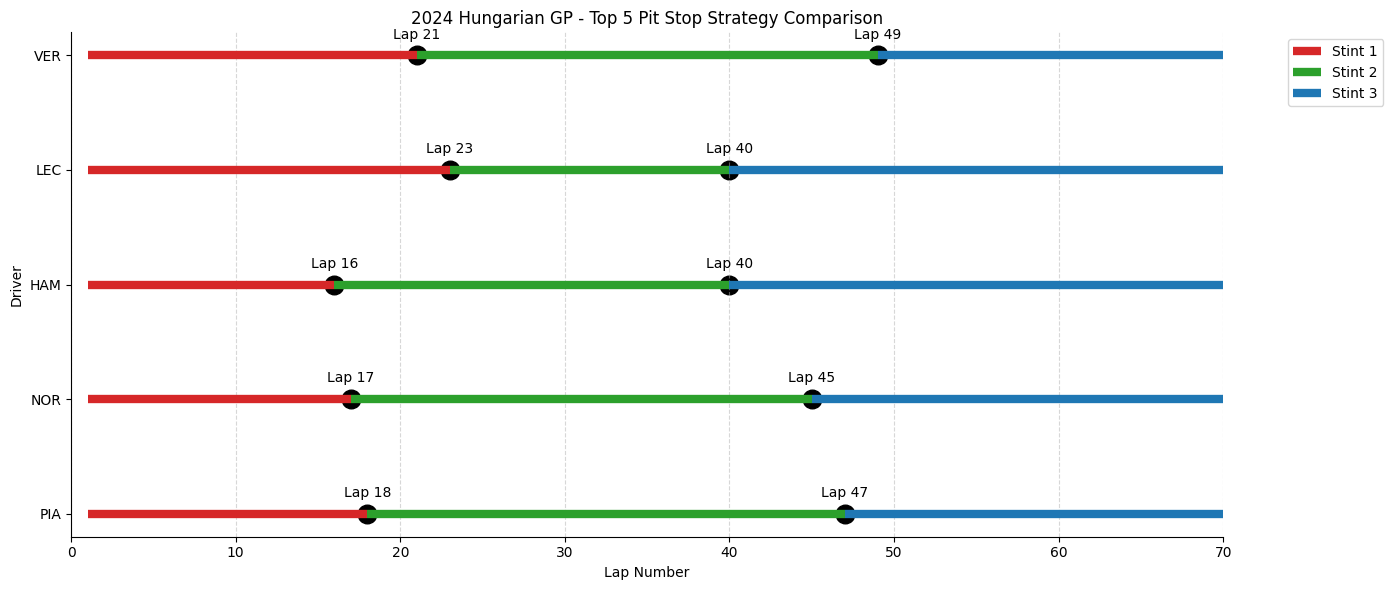

In [32]:
import matplotlib.pyplot as plt

# sort drivers by position
top_5 = top_5.sort_values('Pos.').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))

for i, row in top_5.iterrows():

    # stint 1
    ax.hlines(
        i,
        1,
        row['Pit 1 Lap'],
        color = 'tab:red',
        linewidth = 6
    )
    # stint 2
    ax.hlines(
        i,
        row['Pit 1 Lap'],
        row['Pit 2 Lap'],
        color = 'tab:green',
        linewidth = 6
    )
    # stint 3
    ax.hlines(
        i,
        row['Pit 2 Lap'],
        70,
        color = 'tab:blue',
        linewidth = 6
    )

    # Pit 1
    ax.scatter(
        row['Pit 1 Lap'],
        i,
        s=180,
        color='black'
    )
    # Pit 2
    ax.scatter(
        row['Pit 2 Lap'],
        i,
        s=180,
        color='black'
    )

    # pit-lap number
    ax.annotate(
        f"Lap {int(row['Pit 1 Lap'])}",
        (row['Pit 1 Lap'], i),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center'
    )
    ax.annotate(
        f"Lap {int(row['Pit 2 Lap'])}",
        (row['Pit 2 Lap'], i),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center'
    )

# driver names as labels
ax.set_yticks(range(len(top_5)))
ax.set_yticklabels(top_5['Driver'])

ax.set_xlim(0, 70)

ax.set_xlabel('Lap Number')
ax.set_ylabel('Driver')
ax.set_title('2024 Hungarian GP - Top 5 Pit Stop Strategy Comparison')

ax.grid(axis='x', linestyle='--', alpha=0.5)

# Remove top/right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    ['Stint 1', 'Stint 2', 'Stint 3'],
    loc='upper left',
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout();

In [33]:
# getting insights
winner = top_5.iloc[0]
print(
    f"{winner['Driver']} has won the race using a 2-stop strategy(laps {winner['Pit 1 Lap']} - {winner['Pit 2 Lap']})"
)

PIA has won the race using a 2-stop strategy(laps 18.0 - 47.0)


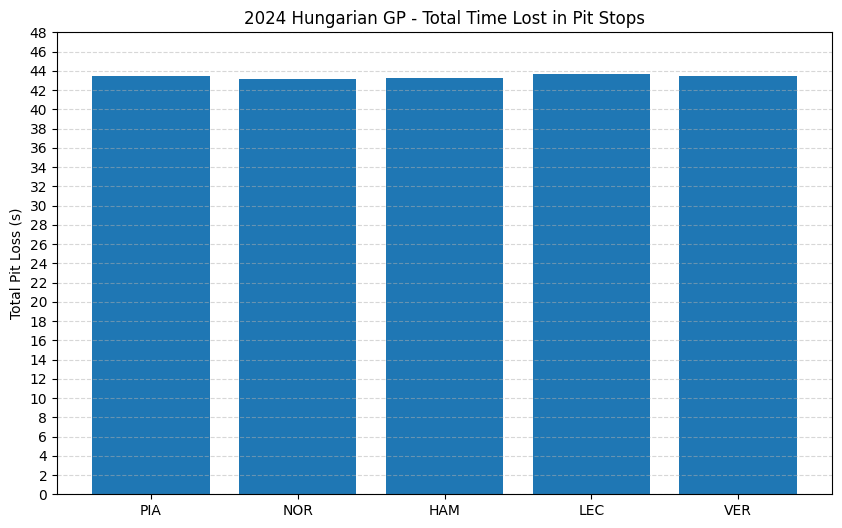

In [34]:
# chart for total time lost in pit stop
plt.figure(figsize=(10, 6))
plt.bar(
    top_5['Driver'],
    top_5['Pit Loss']
)
plt.yticks(range(0, 50, 2))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylabel('Total Pit Loss (s)')
plt.title('2024 Hungarian GP - Total Time Lost in Pit Stops');

**Insights:**

- All top 5 finishing drivers used 2-stop strategy.
- HAM pitted earliest(lap 16), attempting an undercut.
- LEC pitted later(lap 23), running a opening longer stint.
- NOR and PIA followed identical strategies with first stops at lap 17-18 and second stop at lap 45-47.
- VER extended his second stint the longest among the top 5, pitting on lap 49.


In [35]:
# Tyre Stint Analysis
url = 'https://liquipedia.net/formula1/2024_Hungarian_Grand_Prix?utm_source=chatgpt.com'
tables = pd.read_html(url)
len(tables)

16

In [36]:
tables

[   July 21, 2024 - 13:00 GMT                                               \
                         Pos.            Driver   G. +/-     Gap.     Int.   
 0                          1     Oscar Piastri    2  ▲1        -        -   
 1                          2      Lando Norris    1  ▼1   +2.141   +2.141   
 2                          3    Lewis Hamilton    5  ▲2   +14.88  +12.739   
 3                          4   Charles Leclerc    6  ▲2  +19.686   +4.806   
 4                          5    Max Verstappen    3  ▼2  +21.349   +1.663   
 5                          6      Carlos Sainz    4  ▼2  +23.073   +1.724   
 6                          7      Sergio Pérez   16  ▲9  +39.792  +16.719   
 7                          8    George Russell   17  ▲9  +42.368   +2.576   
 8                          9      Yuki Tsunoda   10  ▲1  +77.259  +34.891   
 9                         10      Lance Stroll    8  ▼2  +77.976   +0.717   
 10                        11   Fernando Alonso    7  ▼4   +82.4

In [37]:
tyre_data = tables[0]
tyre_data

July 21, 2024 - 13:00 GMT                                               \
                        Pos.            Driver   G. +/-     Gap.     Int.   
0                          1     Oscar Piastri    2  ▲1        -        -   
1                          2      Lando Norris    1  ▼1   +2.141   +2.141   
2                          3    Lewis Hamilton    5  ▲2   +14.88  +12.739   
3                          4   Charles Leclerc    6  ▲2  +19.686   +4.806   
4                          5    Max Verstappen    3  ▼2  +21.349   +1.663   
5                          6      Carlos Sainz    4  ▼2  +23.073   +1.724   
6                          7      Sergio Pérez   16  ▲9  +39.792  +16.719   
7                          8    George Russell   17  ▲9  +42.368   +2.576   
8                          9      Yuki Tsunoda   10  ▲1  +77.259  +34.891   
9                         10      Lance Stroll    8  ▼2  +77.976   +0.717   
10                        11   Fernando Alonso    7  ▼4   +82.46   +4.484   
11                        12  Daniel Ricciardo    9  ▼3   +82.46   +1 LAP   
12                        13   Nico Hülkenberg   11  ▼2   +1 LAP   +15.26   
13                        14   Alexander Albon   13  ▼1   +1 LAP   +3.585   
14                        15   Kevin Magnussen   15   -   +1 LAP   +8.533   
15                        16   Valtteri Bottas   12  ▼4   +1 LAP   +0.107   
16                        17    Logan Sargeant   14  ▼3   +1 LAP   +7.182   
17                        18      Esteban Ocon   19  ▲1   +1 LAP   +8.338   
18                        19       Zhou Guanyu   18  ▼1   +1 LAP   +2.669   
19                       DNF      Pierre Gasly  PIT   -      DNF      DNF   

                            
   Pits       Tyres Points  
0     2     M, H, M   25.0  
1     2     M, H, M   18.0  
2     2     M, H, H   15.0  
3     2     M, H, M   12.0  
4     2     M, H, M   10.0  
5     2     M, H, M    8.0  
6     2     H, M, M    6.0  
7     2     H, M, H    5.0  
8     1        M, H    2.0  
9     2     S, M, H    1.0  
10    2     S, M, H    NaN  
11    2     M, H, H    NaN  
12    2     M, H, H    NaN  
13    2     S, H, H    NaN  
14    2     S, H, H    NaN  
15    2     M, H, H    NaN  
16    3  M, H, H, S    NaN  
17    3  M, H, H, S    NaN  
18    2     M, H, H    NaN  
19    1        H, M    NaN

In [38]:
# change column names
tyre_data.columns = [['Pos.', 'Driver', 'Grid Pos.', '+/-', 'Gap to first', 'Interval', 'No. of stops', 'Tyre', 'Points']]
tyre_data

,Pos.,Driver,Grid Pos.,+/-,Gap to first,Interval,No. of stops,Tyre,Points
0,1,Oscar Piastri,2,▲1,-,-,2,"M, H, M",25.0
1,2,Lando Norris,1,▼1,+2.141,+2.141,2,"M, H, M",18.0
2,3,Lewis Hamilton,5,▲2,+14.88,+12.739,2,"M, H, H",15.0
3,4,Charles Leclerc,6,▲2,+19.686,+4.806,2,"M, H, M",12.0
4,5,Max Verstappen,3,▼2,+21.349,+1.663,2,"M, H, M",10.0
5,6,Carlos Sainz,4,▼2,+23.073,+1.724,2,"M, H, M",8.0
6,7,Sergio Pérez,16,▲9,+39.792,+16.719,2,"H, M, M",6.0
7,8,George Russell,17,▲9,+42.368,+2.576,2,"H, M, H",5.0
8,9,Yuki Tsunoda,10,▲1,+77.259,+34.891,1,"M, H",2.0
9,10,Lance Stroll,8,▼2,+77.976,+0.717,2,"S, M, H",1.0


In [39]:
tyre_data = tyre_data[[
    'Pos.', 'Driver', 'Tyre'
]]
tyre_data

,Pos.,Driver,Tyre
0,1,Oscar Piastri,"M, H, M"
1,2,Lando Norris,"M, H, M"
2,3,Lewis Hamilton,"M, H, H"
3,4,Charles Leclerc,"M, H, M"
4,5,Max Verstappen,"M, H, M"
5,6,Carlos Sainz,"M, H, M"
6,7,Sergio Pérez,"H, M, M"
7,8,George Russell,"H, M, H"
8,9,Yuki Tsunoda,"M, H"
9,10,Lance Stroll,"S, M, H"


In [40]:
tyre_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   (Pos.,)    20 non-null     object
 1   (Driver,)  20 non-null     object
 2   (Tyre,)    20 non-null     object
dtypes: object(3)
memory usage: 612.0+ bytes


In [41]:
# we can see that columns are list of tuples, change it to a single list
tyre_data.columns = [''.join(col).strip() for col in tyre_data.columns.values]
tyre_data.columns

Index(['Pos.', 'Driver', 'Tyre'], dtype='object')

In [42]:
# convert Pos. to int
tyre_data = tyre_data.copy()
tyre_data['Pos.'] = pd.to_numeric(tyre_data['Pos.'], errors='coerce').astype('Int64')
tyre_data

,Pos.,Driver,Tyre
0,1,Oscar Piastri,"M, H, M"
1,2,Lando Norris,"M, H, M"
2,3,Lewis Hamilton,"M, H, H"
3,4,Charles Leclerc,"M, H, M"
4,5,Max Verstappen,"M, H, M"
5,6,Carlos Sainz,"M, H, M"
6,7,Sergio Pérez,"H, M, M"
7,8,George Russell,"H, M, H"
8,9,Yuki Tsunoda,"M, H"
9,10,Lance Stroll,"S, M, H"


In [43]:
tyre_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Pos.    19 non-null     Int64 
 1   Driver  20 non-null     object
 2   Tyre    20 non-null     object
dtypes: Int64(1), object(2)
memory usage: 632.0+ bytes


In [44]:
tyre_data = tyre_data.sort_values(by = 'Pos.')
tyre_data

,Pos.,Driver,Tyre
0,1,Oscar Piastri,"M, H, M"
1,2,Lando Norris,"M, H, M"
2,3,Lewis Hamilton,"M, H, H"
3,4,Charles Leclerc,"M, H, M"
4,5,Max Verstappen,"M, H, M"
5,6,Carlos Sainz,"M, H, M"
6,7,Sergio Pérez,"H, M, M"
7,8,George Russell,"H, M, H"
8,9,Yuki Tsunoda,"M, H"
9,10,Lance Stroll,"S, M, H"


In [45]:
# add a Driver column from result to tyre_data
tyre_data = pd.merge(
    tyre_data,
    result[['Pos.', 'Driver']],
    how = 'left',
    on = 'Pos.'
)
tyre_data

,Pos.,Driver_x,Tyre,Driver_y
0,1,Oscar Piastri,"M, H, M",PIA
1,2,Lando Norris,"M, H, M",NOR
2,3,Lewis Hamilton,"M, H, H",HAM
3,4,Charles Leclerc,"M, H, M",LEC
4,5,Max Verstappen,"M, H, M",VER
5,6,Carlos Sainz,"M, H, M",SAI
6,7,Sergio Pérez,"H, M, M",PER
7,8,George Russell,"H, M, H",RUS
8,9,Yuki Tsunoda,"M, H",TSU
9,10,Lance Stroll,"S, M, H",STR


In [46]:
tyre_data = tyre_data[[
    'Pos.', 'Driver_y', 'Tyre'
]]
tyre_data = tyre_data.rename(columns = {'Driver_y': 'Driver'})
tyre_data

,Pos.,Driver,Tyre
0,1,PIA,"M, H, M"
1,2,NOR,"M, H, M"
2,3,HAM,"M, H, H"
3,4,LEC,"M, H, M"
4,5,VER,"M, H, M"
5,6,SAI,"M, H, M"
6,7,PER,"H, M, M"
7,8,RUS,"H, M, H"
8,9,TSU,"M, H"
9,10,STR,"S, M, H"


In [47]:
# remove spaces between in tyre column
tyre_data['Tyre'] = tyre_data['Tyre'].str.replace(' ', '')
tyre_data

,Pos.,Driver,Tyre
0,1,PIA,"M,H,M"
1,2,NOR,"M,H,M"
2,3,HAM,"M,H,H"
3,4,LEC,"M,H,M"
4,5,VER,"M,H,M"
5,6,SAI,"M,H,M"
6,7,PER,"H,M,M"
7,8,RUS,"H,M,H"
8,9,TSU,"M,H"
9,10,STR,"S,M,H"


In [48]:
# create the stint table
stints = []
total_laps = 70
for _, row in result.iterrows():

  driver = row['Driver']
  #print(driver)

  final_lap = int(row['Laps'])
  #print(final_lap)

  # since tyre_data is a dataframe, we convert it to dictionary as this is faster than pandas searching the dataframe everytime
  tyre_lookup = dict(
      zip(
          tyre_data['Driver'],
          tyre_data['Tyre']
      )
  )

  tyre_compounds = tyre_lookup[driver].split(',')
  #print(tyre_compounds)

  # different drivers can have different number of pit stops
  pit_laps = []
  for col in result.columns:
    if col.startswith('Pit') and 'Lap' in col:
      if pd.notna(row[col]):
        pit_laps.append(int(row[col]))
  #print(pit_laps)

  # start lap
  start = [1]
  for lap in pit_laps:
    start.append(lap + 1)
  #print(start)

  # end lap
  end = pit_laps.copy()
  #print(total_laps)
  end.append(final_lap)
  #print(end)

  print(driver)
  print("Pit laps:", pit_laps)
  print("Starts:", start)
  print("Ends:", end)
  print("Tyres:", tyre_compounds)

  for tyre, start, end in zip(tyre_compounds, start, end):
    stints.append([
        driver,
        tyre,
        start,
        end
    ])
    print(stints)

PIA
Pit laps: [18, 47]
Starts: [1, 19, 48]
Ends: [18, 47, 70]
Tyres: ['M', 'H', 'M']
[['PIA', 'M', 1, 18]]
[['PIA', 'M', 1, 18], ['PIA', 'H', 19, 47]]
[['PIA', 'M', 1, 18], ['PIA', 'H', 19, 47], ['PIA', 'M', 48, 70]]
NOR
Pit laps: [17, 45]
Starts: [1, 18, 46]
Ends: [17, 45, 70]
Tyres: ['M', 'H', 'M']
[['PIA', 'M', 1, 18], ['PIA', 'H', 19, 47], ['PIA', 'M', 48, 70], ['NOR', 'M', 1, 17]]
[['PIA', 'M', 1, 18], ['PIA', 'H', 19, 47], ['PIA', 'M', 48, 70], ['NOR', 'M', 1, 17], ['NOR', 'H', 18, 45]]
[['PIA', 'M', 1, 18], ['PIA', 'H', 19, 47], ['PIA', 'M', 48, 70], ['NOR', 'M', 1, 17], ['NOR', 'H', 18, 45], ['NOR', 'M', 46, 70]]
HAM
Pit laps: [16, 40]
Starts: [1, 17, 41]
Ends: [16, 40, 70]
Tyres: ['M', 'H', 'H']
[['PIA', 'M', 1, 18], ['PIA', 'H', 19, 47], ['PIA', 'M', 48, 70], ['NOR', 'M', 1, 17], ['NOR', 'H', 18, 45], ['NOR', 'M', 46, 70], ['HAM', 'M', 1, 16]]
[['PIA', 'M', 1, 18], ['PIA', 'H', 19, 47], ['PIA', 'M', 48, 70], ['NOR', 'M', 1, 17], ['NOR', 'H', 18, 45], ['NOR', 'M', 46, 70], ['H

In [49]:
stints_df = pd.DataFrame(stints, columns=['Driver', 'TyreCompound', 'StartLap', 'EndLap'])
stints_df

,Driver,TyreCompound,StartLap,EndLap
0,PIA,M,1,18
1,PIA,H,19,47
2,PIA,M,48,70
3,NOR,M,1,17
4,NOR,H,18,45
5,NOR,M,46,70
6,HAM,M,1,16
7,HAM,H,17,40
8,HAM,H,41,70
9,LEC,M,1,23


In [50]:
# stint length
stints_df['StintLength'] = stints_df['EndLap'] - stints_df['StartLap'] + 1
stints_df

,Driver,TyreCompound,StartLap,EndLap,StintLength
0,PIA,M,1,18,18
1,PIA,H,19,47,29
2,PIA,M,48,70,23
3,NOR,M,1,17,17
4,NOR,H,18,45,28
5,NOR,M,46,70,25
6,HAM,M,1,16,16
7,HAM,H,17,40,24
8,HAM,H,41,70,30
9,LEC,M,1,23,23


In [51]:
# tyre colors
tyre_colors = {
    'S': 'red',
    'M': 'yellow',
    'H': 'white'
}
tyre = {
    'S': 'soft',
    'M': 'medium',
    'H': 'hard'
}

In [52]:
top_5_tyre = stints_df[stints_df['Driver'].isin(top_5['Driver'])]
top_5_tyre

,Driver,TyreCompound,StartLap,EndLap,StintLength
0,PIA,M,1,18,18
1,PIA,H,19,47,29
2,PIA,M,48,70,23
3,NOR,M,1,17,17
4,NOR,H,18,45,28
5,NOR,M,46,70,25
6,HAM,M,1,16,16
7,HAM,H,17,40,24
8,HAM,H,41,70,30
9,LEC,M,1,23,23


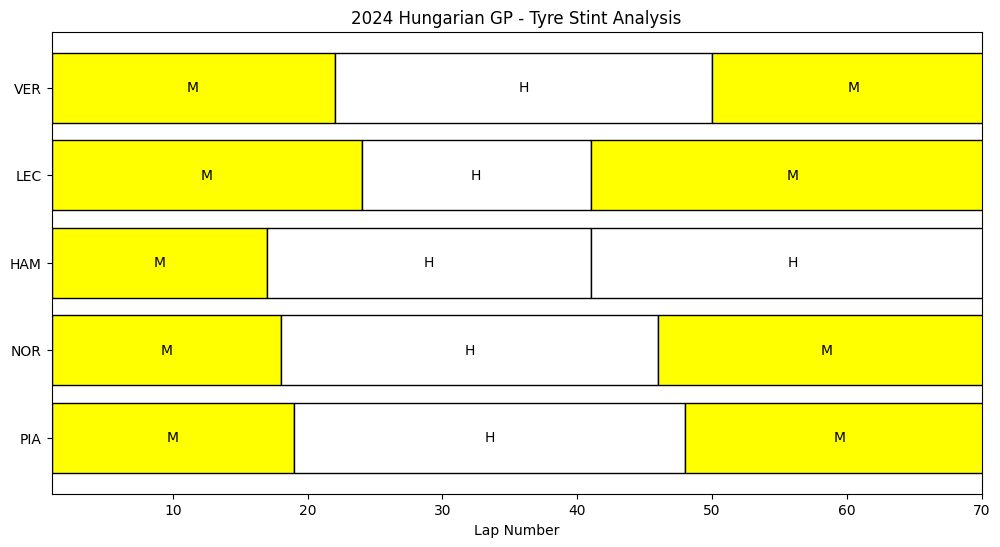

In [53]:
# chart for tyre data
fig, ax = plt.subplots(figsize=(12, 6))
drivers = top_5_tyre['Driver'].unique()
for i, driver in enumerate(drivers):
    driver_data = top_5_tyre[top_5_tyre['Driver'] == driver]

    for _, stint in driver_data.iterrows():
        ax.barh(
            y=i,
            width=stint['StintLength'],
            left=stint['StartLap'],
            color=tyre_colors[stint['TyreCompound']],
            edgecolor='black'
        )
        ax.text(
            stint['StartLap'] + stint['StintLength'] / 2,
            i,
            stint['TyreCompound'],
            ha='center',
            va='center'
        )
ax.set_yticks(range(len(drivers)))
ax.set_yticklabels(drivers)
ax.set_xlabel('Lap Number')
ax.set_title('2024 Hungarian GP - Tyre Stint Analysis')
ax.set_xlim(1, 70);

In [54]:
longest_stint = top_5_tyre.loc[
    top_5_tyre['StintLength'].idxmax()
]
print(
    f"{longest_stint['Driver']} has the longest stint on {tyre[longest_stint['TyreCompound']]} tyres with a length of {longest_stint['StintLength']} laps."
)

HAM has the longest stint on hard tyres with a length of 30 laps.


**Insights:**

- PIA nad NOR executed similar tyre strategy of M-H-M.
- HAM used M-H-H with his last stint as the longest stint of 30 laps on H.
- LEC and VER also used a similar 2-stop strategy on M-H-M, pitting on different laps that showed their different approaches to tyre degradation and race pace.

In [55]:
# Undercut Effectiveness
drivers = pd.read_csv('data/drivers.csv')
lap_times = pd.read_csv('data/lap_times.csv')
races = pd.read_csv('data/races.csv')

In [56]:
drivers

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen
...,...,...,...,...,...,...,...,...,...
860,862,doohan,61,DOO,Jack,Doohan,2003-01-20,Australian,http://en.wikipedia.org/wiki/Jack_Doohan
861,863,antonelli,12,ANT,Andrea Kimi,Antonelli,2006-08-25,Italian,https://en.wikipedia.org/wiki/Andrea_Kimi_Anto...
862,864,bortoleto,5,BOR,Gabriel,Bortoleto,2004-10-14,Brazilian,https://en.wikipedia.org/wiki/Gabriel_Bortoleto
863,865,hadjar,6,HAD,Isack,Hadjar,2004-09-28,French,https://en.wikipedia.org/wiki/Isack_Hadjar


In [57]:
lap_times

,raceId,driverId,lap,position,time,milliseconds
0,479,137,1,1,1:42.085,102085
1,479,137,2,2,1:36.287,96287
2,479,137,3,2,1:34.627,94627
3,479,137,4,2,1:34.041,94041
4,479,137,5,2,1:33.699,93699
...,...,...,...,...,...,...
875088,1176,857,71,4,1:12.503,72503
875089,1176,1,71,5,1:12.909,72909
875090,1176,865,71,6,1:12.638,72638
875091,1176,846,71,7,1:12.739,72739


In [58]:
races

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,1186,2026,18,32,Mexico City Grand Prix,2026-11-01,20:00:00,https://en.wikipedia.org/wiki/2026_Mexico_City...,2026-10-30,18:30:00,2026-10-30,22:00:00,2026-10-31,17:30:00,2026-10-31,21:00:00,\N,\N
1167,1187,2026,19,18,Brazilian Grand Prix,2026-11-08,17:00:00,https://en.wikipedia.org/wiki/2026_Brazilian_G...,2026-11-06,15:30:00,2026-11-06,19:00:00,2026-11-07,14:30:00,2026-11-07,18:00:00,\N,\N
1168,1188,2026,20,80,Las Vegas Grand Prix,2026-11-22,04:00:00,https://en.wikipedia.org/wiki/2026_Las_Vegas_G...,2026-11-20,00:30:00,2026-11-20,04:00:00,2026-11-21,00:30:00,2026-11-21,04:00:00,\N,\N
1169,1189,2026,21,78,Qatar Grand Prix,2026-11-29,16:00:00,https://en.wikipedia.org/wiki/2026_Qatar_Grand...,2026-11-27,13:30:00,2026-11-27,17:00:00,2026-11-28,14:30:00,2026-11-28,18:00:00,\N,\N


In [59]:
# combine lap_times with races
lap_times = pd.merge(
    lap_times,
    races[['raceId', 'year', 'name']],
    how = 'left',
    on = 'raceId'
)
lap_times

,raceId,driverId,lap,position,time,milliseconds,year,name
0,479,137,1,1,1:42.085,102085,1982,Austrian Grand Prix
1,479,137,2,2,1:36.287,96287,1982,Austrian Grand Prix
2,479,137,3,2,1:34.627,94627,1982,Austrian Grand Prix
3,479,137,4,2,1:34.041,94041,1982,Austrian Grand Prix
4,479,137,5,2,1:33.699,93699,1982,Austrian Grand Prix
...,...,...,...,...,...,...,...,...
875088,1176,857,71,4,1:12.503,72503,2026,Austrian Grand Prix
875089,1176,1,71,5,1:12.909,72909,2026,Austrian Grand Prix
875090,1176,865,71,6,1:12.638,72638,2026,Austrian Grand Prix
875091,1176,846,71,7,1:12.739,72739,2026,Austrian Grand Prix


In [60]:
# only get the Hungarian GP from year 2024 laptime data
lap_times = lap_times[
    (lap_times['year'] == 2024) &
    (lap_times['name'] == 'Hungarian Grand Prix')
]
lap_times

,raceId,driverId,lap,position,time,milliseconds,year,name
826055,1133,857,1,1,1:26.746,86746,2024,Hungarian Grand Prix
826056,1133,857,2,1,1:24.038,84038,2024,Hungarian Grand Prix
826057,1133,857,3,1,1:24.401,84401,2024,Hungarian Grand Prix
826058,1133,857,4,1,1:24.115,84115,2024,Hungarian Grand Prix
826059,1133,857,5,1,1:23.796,83796,2024,Hungarian Grand Prix
...,...,...,...,...,...,...,...,...
827405,1133,842,29,19,1:41.671,101671,2024,Hungarian Grand Prix
827406,1133,842,30,17,1:23.446,83446,2024,Hungarian Grand Prix
827407,1133,842,31,16,1:23.340,83340,2024,Hungarian Grand Prix
827408,1133,842,32,15,1:23.484,83484,2024,Hungarian Grand Prix


In [61]:
lap_times['name'].unique()

array(['Hungarian Grand Prix'], dtype=object)

In [62]:
lap_times['year'].unique()

array([2024])

In [63]:
# merge lap_times and drivers
lap_times = pd.merge(
    lap_times,
    drivers[['driverId', 'code']],
    how = 'left',
    on = 'driverId'
)
lap_times

,raceId,driverId,lap,position,time,milliseconds,year,name,code
0,1133,857,1,1,1:26.746,86746,2024,Hungarian Grand Prix,PIA
1,1133,857,2,1,1:24.038,84038,2024,Hungarian Grand Prix,PIA
2,1133,857,3,1,1:24.401,84401,2024,Hungarian Grand Prix,PIA
3,1133,857,4,1,1:24.115,84115,2024,Hungarian Grand Prix,PIA
4,1133,857,5,1,1:23.796,83796,2024,Hungarian Grand Prix,PIA
...,...,...,...,...,...,...,...,...,...
1350,1133,842,29,19,1:41.671,101671,2024,Hungarian Grand Prix,GAS
1351,1133,842,30,17,1:23.446,83446,2024,Hungarian Grand Prix,GAS
1352,1133,842,31,16,1:23.340,83340,2024,Hungarian Grand Prix,GAS
1353,1133,842,32,15,1:23.484,83484,2024,Hungarian Grand Prix,GAS


In [64]:
lap_times.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   raceId        1355 non-null   int64 
 1   driverId      1355 non-null   int64 
 2   lap           1355 non-null   int64 
 3   position      1355 non-null   int64 
 4   time          1355 non-null   object
 5   milliseconds  1355 non-null   int64 
 6   year          1355 non-null   int64 
 7   name          1355 non-null   object
 8   code          1355 non-null   object
dtypes: int64(6), object(3)
memory usage: 95.4+ KB


In [65]:
# change time from milliseconds to seconds
lap_times = lap_times.copy()
lap_times['seconds'] = lap_times['milliseconds'] / 1000
lap_times

,raceId,driverId,lap,position,time,milliseconds,year,name,code,seconds
0,1133,857,1,1,1:26.746,86746,2024,Hungarian Grand Prix,PIA,86.746
1,1133,857,2,1,1:24.038,84038,2024,Hungarian Grand Prix,PIA,84.038
2,1133,857,3,1,1:24.401,84401,2024,Hungarian Grand Prix,PIA,84.401
3,1133,857,4,1,1:24.115,84115,2024,Hungarian Grand Prix,PIA,84.115
4,1133,857,5,1,1:23.796,83796,2024,Hungarian Grand Prix,PIA,83.796
...,...,...,...,...,...,...,...,...,...,...
1350,1133,842,29,19,1:41.671,101671,2024,Hungarian Grand Prix,GAS,101.671
1351,1133,842,30,17,1:23.446,83446,2024,Hungarian Grand Prix,GAS,83.446
1352,1133,842,31,16,1:23.340,83340,2024,Hungarian Grand Prix,GAS,83.340
1353,1133,842,32,15,1:23.484,83484,2024,Hungarian Grand Prix,GAS,83.484


In [66]:
# lets get the columns that we need
lap_times = lap_times[[
    'code',
    'lap',
    'position',
    'time',
    'seconds'
]]
lap_times

,code,lap,position,time,seconds
0,PIA,1,1,1:26.746,86.746
1,PIA,2,1,1:24.038,84.038
2,PIA,3,1,1:24.401,84.401
3,PIA,4,1,1:24.115,84.115
4,PIA,5,1,1:23.796,83.796
...,...,...,...,...,...
1350,GAS,29,19,1:41.671,101.671
1351,GAS,30,17,1:23.446,83.446
1352,GAS,31,16,1:23.340,83.340
1353,GAS,32,15,1:23.484,83.484


In [67]:
# change column names
lap_times.columns = [
        'Driver',
        'Lap',
        'Position',
        'Lap Time',
        'Lap Time (sec)'
    ]
lap_times

,Driver,Lap,Position,Lap Time,Lap Time (sec)
0,PIA,1,1,1:26.746,86.746
1,PIA,2,1,1:24.038,84.038
2,PIA,3,1,1:24.401,84.401
3,PIA,4,1,1:24.115,84.115
4,PIA,5,1,1:23.796,83.796
...,...,...,...,...,...
1350,GAS,29,19,1:41.671,101.671
1351,GAS,30,17,1:23.446,83.446
1352,GAS,31,16,1:23.340,83.340
1353,GAS,32,15,1:23.484,83.484


In [68]:
# merge lap_times and pit
lap_pit_data = pd.merge(
    lap_times,
    pit[['Driver', 'Lap', 'Stops', 'Pit Time (sec)', 'Total Pit Time (sec)']],
    how = 'left',
    on = ['Driver', 'Lap']
)
lap_pit_data

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec)
0,PIA,1,1,1:26.746,86.746,NaN,NaN,NaN
1,PIA,2,1,1:24.038,84.038,NaN,NaN,NaN
2,PIA,3,1,1:24.401,84.401,NaN,NaN,NaN
3,PIA,4,1,1:24.115,84.115,NaN,NaN,NaN
4,PIA,5,1,1:23.796,83.796,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1350,GAS,29,19,1:41.671,101.671,NaN,NaN,NaN
1351,GAS,30,17,1:23.446,83.446,NaN,NaN,NaN
1352,GAS,31,16,1:23.340,83.340,NaN,NaN,NaN
1353,GAS,32,15,1:23.484,83.484,NaN,NaN,NaN


In [69]:
# undercut effectiveness using positions
undercut_position = lap_pit_data[lap_pit_data['Stops'].notna()].copy()
undercut_position['Position Before Pit Stop'] = lap_pit_data.groupby('Driver')['Position'].shift(1)
undercut_position

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec),Position Before Pit Stop
17,PIA,18,1,1:26.496,86.496,1.0,21.641,21.641,1.0
46,PIA,47,1,1:26.252,86.252,2.0,21.823,43.464,1.0
90,VER,21,1,1:27.027,87.027,1.0,22.101,22.101,1.0
118,VER,49,1,1:26.468,86.468,2.0,21.344,43.445,1.0
156,NOR,17,2,1:26.485,86.485,1.0,21.861,21.861,2.0
184,NOR,45,2,1:26.328,86.328,2.0,21.249,43.110,2.0
225,HAM,16,5,1:27.246,87.246,1.0,21.306,21.306,4.0
249,HAM,40,4,1:27.733,87.733,2.0,21.910,43.216,3.0
302,LEC,23,1,1:26.918,86.918,1.0,21.894,21.894,1.0
319,LEC,40,5,1:27.274,87.274,2.0,21.723,43.617,5.0


In [70]:
# for a pit cycle, we considered 5th positions after pit
# stint is stabilized and closest drivers have completed thier pit stops
undercut_position['Position After Pit Cycle'] = undercut_position.apply(
    lambda row: lap_pit_data[
        (lap_pit_data['Driver'] == row['Driver']) &
        (lap_pit_data['Lap'] == row['Lap'] + 5)
    ]['Position'].iloc[0]
    if len(
        lap_pit_data[
            (lap_pit_data['Driver'] == row['Driver']) &
            (lap_pit_data['Lap'] == row['Lap'] + 5)
        ]
    ) > 0
    else None,
    axis = 1
)
undercut_position

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec),Position Before Pit Stop,Position After Pit Cycle
17,PIA,18,1,1:26.496,86.496,1.0,21.641,21.641,1.0,2
46,PIA,47,1,1:26.252,86.252,2.0,21.823,43.464,1.0,2
90,VER,21,1,1:27.027,87.027,1.0,22.101,22.101,1.0,4
118,VER,49,1,1:26.468,86.468,2.0,21.344,43.445,1.0,5
156,NOR,17,2,1:26.485,86.485,1.0,21.861,21.861,2.0,3
184,NOR,45,2,1:26.328,86.328,2.0,21.249,43.110,2.0,1
225,HAM,16,5,1:27.246,87.246,1.0,21.306,21.306,4.0,6
249,HAM,40,4,1:27.733,87.733,2.0,21.910,43.216,3.0,5
302,LEC,23,1,1:26.918,86.918,1.0,21.894,21.894,1.0,5
319,LEC,40,5,1:27.274,87.274,2.0,21.723,43.617,5.0,6


In [71]:
undercut_position['Position Gain'] = (
    undercut_position['Position Before Pit Stop'] - undercut_position['Position After Pit Cycle']
)
undercut_position

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec),Position Before Pit Stop,Position After Pit Cycle,Position Gain
17,PIA,18,1,1:26.496,86.496,1.0,21.641,21.641,1.0,2,-1.0
46,PIA,47,1,1:26.252,86.252,2.0,21.823,43.464,1.0,2,-1.0
90,VER,21,1,1:27.027,87.027,1.0,22.101,22.101,1.0,4,-3.0
118,VER,49,1,1:26.468,86.468,2.0,21.344,43.445,1.0,5,-4.0
156,NOR,17,2,1:26.485,86.485,1.0,21.861,21.861,2.0,3,-1.0
184,NOR,45,2,1:26.328,86.328,2.0,21.249,43.110,2.0,1,1.0
225,HAM,16,5,1:27.246,87.246,1.0,21.306,21.306,4.0,6,-2.0
249,HAM,40,4,1:27.733,87.733,2.0,21.910,43.216,3.0,5,-2.0
302,LEC,23,1,1:26.918,86.918,1.0,21.894,21.894,1.0,5,-4.0
319,LEC,40,5,1:27.274,87.274,2.0,21.723,43.617,5.0,6,-1.0


In [72]:
# undercut effectiveness using laptime
undercut_results = []
for _, stop in undercut_position.iterrows():
    driver = stop['Driver']
    pit_lap = stop['Lap']

    # before - avg of 5 laptimes before pit
    before = lap_pit_data[
        (lap_pit_data['Driver'] == driver) &
        (lap_pit_data['Lap'].between(pit_lap - 5, pit_lap - 1))
    ]['Lap Time (sec)'].mean()

    # after - avg of 5 laptimes after pit_lap + 2
    # pit_lap + 2 - beacuse 1 lap after pit_lap is an out-lap
    after = lap_pit_data[
        (lap_pit_data['Driver'] == driver) &
        (lap_pit_data['Lap'].between(pit_lap + 2, pit_lap + 6))
    ]['Lap Time (sec)'].mean()

    gain_per_lap = before - after
    gain = gain_per_lap * 5

    undercut_results.append([
        driver,
        pit_lap,
        round(before, 3),
        round(after, 3),
        round(gain, 3)
    ])
undercut_results

[['PIA', 18, np.float64(84.271), np.float64(83.308), np.float64(4.813)],
 ['PIA', 47, np.float64(84.124), np.float64(82.039), np.float64(10.422)],
 ['VER', 21, np.float64(84.637), np.float64(82.743), np.float64(9.47)],
 ['VER', 49, np.float64(84.006), np.float64(81.89), np.float64(10.578)],
 ['NOR', 17, np.float64(84.276), np.float64(83.566), np.float64(3.552)],
 ['NOR', 45, np.float64(84.153), np.float64(82.208), np.float64(9.722)],
 ['HAM', 16, np.float64(84.554), np.float64(83.307), np.float64(6.238)],
 ['HAM', 40, np.float64(84.895), np.float64(82.926), np.float64(9.844)],
 ['LEC', 23, np.float64(84.569), np.float64(82.76), np.float64(9.047)],
 ['LEC', 40, np.float64(84.282), np.float64(82.976), np.float64(6.529)],
 ['ALO', 7, np.float64(86.167), np.float64(84.999), np.float64(5.839)],
 ['ALO', 37, np.float64(84.515), np.float64(83.755), np.float64(3.798)],
 ['SAI', 21, np.float64(84.862), np.float64(83.896), np.float64(4.83)],
 ['SAI', 47, np.float64(83.963), np.float64(81.83), np

In [73]:
undercut_laptimes = pd.DataFrame(
    undercut_results,
    columns=['Driver', 'Lap', 'Avg Lap Time Before Pit', 'Avg Lap Time After Pit', 'Gain']
)
undercut_laptimes

,Driver,Lap,Avg Lap Time Before Pit,Avg Lap Time After Pit,Gain
0,PIA,18,84.271,83.308,4.813
1,PIA,47,84.124,82.039,10.422
2,VER,21,84.637,82.743,9.470
3,VER,49,84.006,81.890,10.578
4,NOR,17,84.276,83.566,3.552
5,NOR,45,84.153,82.208,9.722
6,HAM,16,84.554,83.307,6.238
7,HAM,40,84.895,82.926,9.844
8,LEC,23,84.569,82.760,9.047
9,LEC,40,84.282,82.976,6.529


In [74]:
# combine pit_stops(undercut by positions) and undercut_df(undercut by laptimes)
undercut_effectiveness = pd.merge(
    undercut_position,
    undercut_laptimes,
    how = 'left',
    on = ['Driver', 'Lap']
)
undercut_effectiveness

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec),Position Before Pit Stop,Position After Pit Cycle,Position Gain,Avg Lap Time Before Pit,Avg Lap Time After Pit,Gain
0,PIA,18,1,1:26.496,86.496,1.0,21.641,21.641,1.0,2,-1.0,84.271,83.308,4.813
1,PIA,47,1,1:26.252,86.252,2.0,21.823,43.464,1.0,2,-1.0,84.124,82.039,10.422
2,VER,21,1,1:27.027,87.027,1.0,22.101,22.101,1.0,4,-3.0,84.637,82.743,9.470
3,VER,49,1,1:26.468,86.468,2.0,21.344,43.445,1.0,5,-4.0,84.006,81.890,10.578
4,NOR,17,2,1:26.485,86.485,1.0,21.861,21.861,2.0,3,-1.0,84.276,83.566,3.552
5,NOR,45,2,1:26.328,86.328,2.0,21.249,43.110,2.0,1,1.0,84.153,82.208,9.722
6,HAM,16,5,1:27.246,87.246,1.0,21.306,21.306,4.0,6,-2.0,84.554,83.307,6.238
7,HAM,40,4,1:27.733,87.733,2.0,21.910,43.216,3.0,5,-2.0,84.895,82.926,9.844
8,LEC,23,1,1:26.918,86.918,1.0,21.894,21.894,1.0,5,-4.0,84.569,82.760,9.047
9,LEC,40,5,1:27.274,87.274,2.0,21.723,43.617,5.0,6,-1.0,84.282,82.976,6.529


In [75]:
undercut_effectiveness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Driver                    40 non-null     object 
 1   Lap                       40 non-null     int64  
 2   Position                  40 non-null     int64  
 3   Lap Time                  40 non-null     object 
 4   Lap Time (sec)            40 non-null     float64
 5   Stops                     40 non-null     float64
 6   Pit Time (sec)            40 non-null     float64
 7   Total Pit Time (sec)      40 non-null     float64
 8   Position Before Pit Stop  40 non-null     float64
 9   Position After Pit Cycle  40 non-null     int64  
 10  Position Gain             40 non-null     float64
 11  Avg Lap Time Before Pit   40 non-null     float64
 12  Avg Lap Time After Pit    40 non-null     float64
 13  Gain                      40 non-null     float64
dtypes: float64(9

In [76]:
top_5

,No.,Driver,Team,Pit 1 Lap,Pit 2 Lap,Pit 3 Lap,Pit 1 time,Pit 2 time,Pit 3 time,No. of stops,Pit Loss,Pos.,Laps
0,81,PIA,McLaren Mercedes,18.0,47.0,NaN,21.641,21.823,NaN,2,43.464,1,70
1,4,NOR,McLaren Mercedes,17.0,45.0,NaN,21.861,21.249,NaN,2,43.110,2,70
2,44,HAM,Mercedes,16.0,40.0,NaN,21.306,21.910,NaN,2,43.216,3,70
3,16,LEC,Ferrari,23.0,40.0,NaN,21.894,21.723,NaN,2,43.617,4,70
4,1,VER,Red Bull Racing Honda RBPT,21.0,49.0,NaN,22.101,21.344,NaN,2,43.445,5,70


In [77]:
top_5_undercut = undercut_effectiveness[undercut_effectiveness['Driver'].isin(top_5['Driver'])]
top_5_undercut

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec),Position Before Pit Stop,Position After Pit Cycle,Position Gain,Avg Lap Time Before Pit,Avg Lap Time After Pit,Gain
0,PIA,18,1,1:26.496,86.496,1.0,21.641,21.641,1.0,2,-1.0,84.271,83.308,4.813
1,PIA,47,1,1:26.252,86.252,2.0,21.823,43.464,1.0,2,-1.0,84.124,82.039,10.422
2,VER,21,1,1:27.027,87.027,1.0,22.101,22.101,1.0,4,-3.0,84.637,82.743,9.470
3,VER,49,1,1:26.468,86.468,2.0,21.344,43.445,1.0,5,-4.0,84.006,81.890,10.578
4,NOR,17,2,1:26.485,86.485,1.0,21.861,21.861,2.0,3,-1.0,84.276,83.566,3.552
5,NOR,45,2,1:26.328,86.328,2.0,21.249,43.110,2.0,1,1.0,84.153,82.208,9.722
6,HAM,16,5,1:27.246,87.246,1.0,21.306,21.306,4.0,6,-2.0,84.554,83.307,6.238
7,HAM,40,4,1:27.733,87.733,2.0,21.910,43.216,3.0,5,-2.0,84.895,82.926,9.844
8,LEC,23,1,1:26.918,86.918,1.0,21.894,21.894,1.0,5,-4.0,84.569,82.760,9.047
9,LEC,40,5,1:27.274,87.274,2.0,21.723,43.617,5.0,6,-1.0,84.282,82.976,6.529


In [78]:
top_5_undercut = top_5_undercut.copy()
top_5_undercut['Label'] = top_5_undercut['Driver'] + '-' + top_5_undercut['Lap'].astype(str)
top_5_undercut

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec),Position Before Pit Stop,Position After Pit Cycle,Position Gain,Avg Lap Time Before Pit,Avg Lap Time After Pit,Gain,Label
0,PIA,18,1,1:26.496,86.496,1.0,21.641,21.641,1.0,2,-1.0,84.271,83.308,4.813,PIA-18
1,PIA,47,1,1:26.252,86.252,2.0,21.823,43.464,1.0,2,-1.0,84.124,82.039,10.422,PIA-47
2,VER,21,1,1:27.027,87.027,1.0,22.101,22.101,1.0,4,-3.0,84.637,82.743,9.470,VER-21
3,VER,49,1,1:26.468,86.468,2.0,21.344,43.445,1.0,5,-4.0,84.006,81.890,10.578,VER-49
4,NOR,17,2,1:26.485,86.485,1.0,21.861,21.861,2.0,3,-1.0,84.276,83.566,3.552,NOR-17
5,NOR,45,2,1:26.328,86.328,2.0,21.249,43.110,2.0,1,1.0,84.153,82.208,9.722,NOR-45
6,HAM,16,5,1:27.246,87.246,1.0,21.306,21.306,4.0,6,-2.0,84.554,83.307,6.238,HAM-16
7,HAM,40,4,1:27.733,87.733,2.0,21.910,43.216,3.0,5,-2.0,84.895,82.926,9.844,HAM-40
8,LEC,23,1,1:26.918,86.918,1.0,21.894,21.894,1.0,5,-4.0,84.569,82.760,9.047,LEC-23
9,LEC,40,5,1:27.274,87.274,2.0,21.723,43.617,5.0,6,-1.0,84.282,82.976,6.529,LEC-40


In [79]:
!pip install adjustText

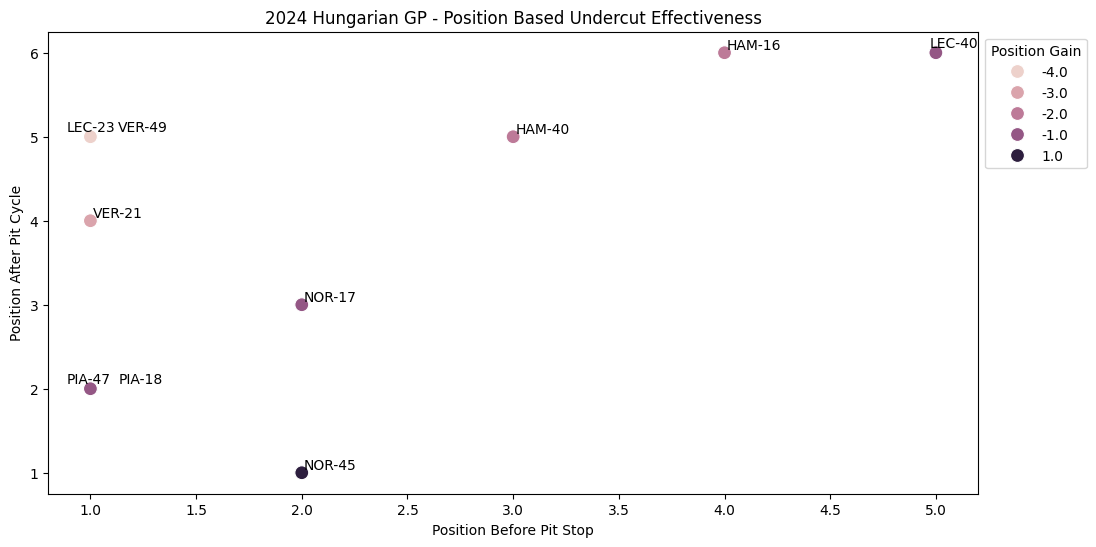

In [80]:
# chart for position based undercut
import seaborn as sns
import adjustText as adjust_text
plt.figure(figsize = (12, 6))
sns.scatterplot(
    data = top_5_undercut,
    x = 'Position Before Pit Stop',
    y = 'Position After Pit Cycle',
    hue = 'Position Gain',
    s = 100
)
text = []
for _, row in top_5_undercut.iterrows():
    text.append(
        plt.text(
            row['Position Before Pit Stop'],
            row['Position After Pit Cycle'],
            f"{row['Label']}"
        )
    )
adjust_text.adjust_text(text)
plt.title('2024 Hungarian GP - Position Based Undercut Effectiveness')
plt.xlabel('Position Before Pit Stop')
plt.ylabel('Position After Pit Cycle')
plt.legend(
    title = 'Position Gain',
    bbox_to_anchor = (1, 1)
);

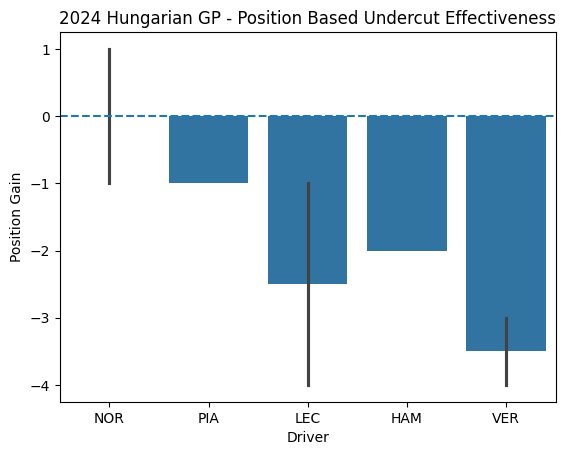

In [81]:
# bar chart would make this clear
sns.barplot(
    data = top_5_undercut.sort_values(by = 'Position Gain', ascending = False),
    x = 'Driver',
    y = 'Position Gain'
)
plt.axhline(y = 0, linestyle = '--')
plt.title('2024 Hungarian GP - Position Based Undercut Effectiveness')
plt.xlabel('Driver')
plt.ylabel('Position Gain');

**Insights:**

- NOR was the only driver to gain a position through a pit cycle of 5 laps from P2 to P1 after his pit-stop at lap 45.
- Most drivers lost positions immediately after pitting as driver has to drive slow in the pit-lane as well as need ~2secs for tyre change.
- Undercut effectivess was limited in terms of positions gained so we calculated it using laptimes gain over 5 laps after an out-lap.

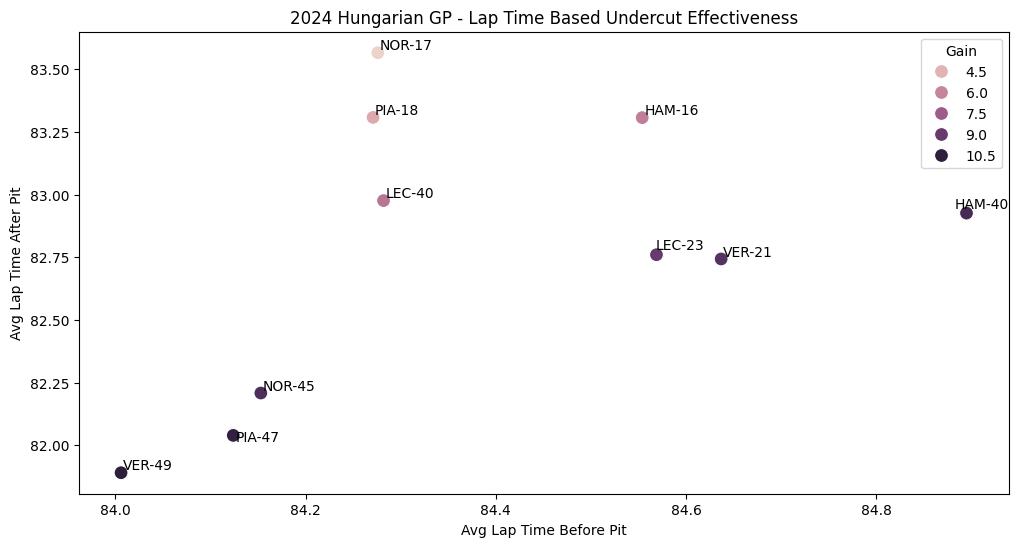

In [82]:
# chart for lap time based undercut
plt.figure(figsize = (12, 6))
sns.scatterplot(
    data = top_5_undercut,
    x = 'Avg Lap Time Before Pit',
    y = 'Avg Lap Time After Pit',
    hue = 'Gain',
    s = 100
)
text = []
for _, row in top_5_undercut.iterrows():
    text.append(
        plt.text(
            row['Avg Lap Time Before Pit'],
            row['Avg Lap Time After Pit'],
            f"{row['Label']}"
        )
    )
adjust_text.adjust_text(text)
plt.title('2024 Hungarian GP - Lap Time Based Undercut Effectiveness')
plt.xlabel('Avg Lap Time Before Pit')
plt.ylabel('Avg Lap Time After Pit')
plt.legend(
    title = 'Gain',
    bbox_to_anchor = (1, 1)
);

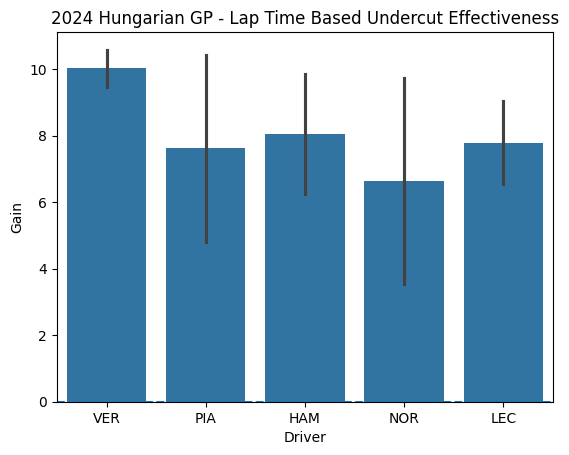

In [83]:
# bar chart would make this clear
sns.barplot(
    data = top_5_undercut.sort_values(by = 'Gain', ascending = False),
    x = 'Driver',
    y = 'Gain'
)
plt.axhline(y = 0, linestyle = '--')
plt.title('2024 Hungarian GP - Lap Time Based Undercut Effectiveness')
plt.xlabel('Driver')
plt.ylabel('Gain');

**Insights:**
- VER achieved the highest average gain, ~10 secs over the analysed window.
- McLarens achieved average gains of ~8 secs for PIA and ~7 secs for NOR. NOR was slow but was the only driver to gain a position.
- HAM and LEC, both benefitted from fresh tyres but their average gain were smaller as compared to VER.

In [84]:
# Driver Race Pace Comparison
lap_pit_data

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec)
0,PIA,1,1,1:26.746,86.746,NaN,NaN,NaN
1,PIA,2,1,1:24.038,84.038,NaN,NaN,NaN
2,PIA,3,1,1:24.401,84.401,NaN,NaN,NaN
3,PIA,4,1,1:24.115,84.115,NaN,NaN,NaN
4,PIA,5,1,1:23.796,83.796,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1350,GAS,29,19,1:41.671,101.671,NaN,NaN,NaN
1351,GAS,30,17,1:23.446,83.446,NaN,NaN,NaN
1352,GAS,31,16,1:23.340,83.340,NaN,NaN,NaN
1353,GAS,32,15,1:23.484,83.484,NaN,NaN,NaN


In [85]:
# remove pit-laps
clean_data = lap_pit_data.copy()
clean_data = clean_data[
    clean_data['Stops'].isna()
]
clean_data

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec)
0,PIA,1,1,1:26.746,86.746,NaN,NaN,NaN
1,PIA,2,1,1:24.038,84.038,NaN,NaN,NaN
2,PIA,3,1,1:24.401,84.401,NaN,NaN,NaN
3,PIA,4,1,1:24.115,84.115,NaN,NaN,NaN
4,PIA,5,1,1:23.796,83.796,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1350,GAS,29,19,1:41.671,101.671,NaN,NaN,NaN
1351,GAS,30,17,1:23.446,83.446,NaN,NaN,NaN
1352,GAS,31,16,1:23.340,83.340,NaN,NaN,NaN
1353,GAS,32,15,1:23.484,83.484,NaN,NaN,NaN


In [86]:
# remove out-laps
out_laps = []
for driver in lap_pit_data['Driver'].unique():
  driver_data = lap_pit_data[
      lap_pit_data['Driver'] == driver
  ]
  pit_laps = driver_data[
      driver_data['Stops'].notna()
  ]['Lap']
  for pit_lap in pit_laps:
    out_laps.append(
        (driver, pit_lap + 1)
    )
out_laps

[('PIA', 19),
 ('PIA', 48),
 ('VER', 22),
 ('VER', 50),
 ('NOR', 18),
 ('NOR', 46),
 ('HAM', 17),
 ('HAM', 41),
 ('LEC', 24),
 ('LEC', 41),
 ('ALO', 8),
 ('ALO', 38),
 ('SAI', 22),
 ('SAI', 48),
 ('STR', 15),
 ('STR', 46),
 ('ALB', 7),
 ('ALB', 30),
 ('MAG', 7),
 ('MAG', 35),
 ('RIC', 8),
 ('RIC', 29),
 ('TSU', 30),
 ('BOT', 17),
 ('BOT', 46),
 ('HUL', 3),
 ('HUL', 30),
 ('OCO', 7),
 ('OCO', 31),
 ('OCO', 65),
 ('RUS', 34),
 ('RUS', 54),
 ('PER', 29),
 ('PER', 48),
 ('SAR', 9),
 ('SAR', 34),
 ('SAR', 64),
 ('ZHO', 8),
 ('ZHO', 37),
 ('GAS', 29)]

In [87]:
clean_data = clean_data[
    ~clean_data.apply(
        lambda row: (row['Driver'], row['Lap']) in out_laps,
        axis = 1
    )
]
clean_data

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec)
0,PIA,1,1,1:26.746,86.746,NaN,NaN,NaN
1,PIA,2,1,1:24.038,84.038,NaN,NaN,NaN
2,PIA,3,1,1:24.401,84.401,NaN,NaN,NaN
3,PIA,4,1,1:24.115,84.115,NaN,NaN,NaN
4,PIA,5,1,1:23.796,83.796,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1348,GAS,27,10,1:26.206,86.206,NaN,NaN,NaN
1351,GAS,30,17,1:23.446,83.446,NaN,NaN,NaN
1352,GAS,31,16,1:23.340,83.340,NaN,NaN,NaN
1353,GAS,32,15,1:23.484,83.484,NaN,NaN,NaN


In [88]:
# avg race pace per driver
avg_race_pace = (
    clean_data.groupby('Driver')['Lap Time (sec)']
    .mean()
    .reset_index()
    .rename(columns = {'Lap Time (sec)': 'Avg Race Pace (sec)'})
)
avg_race_pace = avg_race_pace.sort_values(by = 'Avg Race Pace (sec)')
avg_race_pace

,Driver,Avg Race Pace (sec)
11,PIA,83.414818
8,NOR,83.493318
4,HAM,83.644788
6,LEC,83.706652
14,SAI,83.757500
18,VER,83.769167
10,PER,84.023955
13,RUS,84.122091
16,STR,84.512848
1,ALO,84.649136


In [89]:
top_5_avg_race_pace = avg_race_pace[avg_race_pace['Driver'].isin(top_5['Driver'])]
top_5_avg_race_pace

,Driver,Avg Race Pace (sec)
11,PIA,83.414818
8,NOR,83.493318
4,HAM,83.644788
6,LEC,83.706652
18,VER,83.769167


In [90]:
# fastest among top 5 finishing drivers
fastest_avg_race_pace = top_5_avg_race_pace.iloc[0]
print(
    f"{fastest_avg_race_pace['Driver']} has the fastest average race pace of {round(fastest_avg_race_pace['Avg Race Pace (sec)'], 3)} seconds."
)

PIA has the fastest average race pace of 83.415 seconds.


In [91]:
top_5_clean_data = clean_data[clean_data['Driver'].isin(top_5['Driver'])]
top_5_clean_data

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec)
0,PIA,1,1,1:26.746,86.746,NaN,NaN,NaN
1,PIA,2,1,1:24.038,84.038,NaN,NaN,NaN
2,PIA,3,1,1:24.401,84.401,NaN,NaN,NaN
3,PIA,4,1,1:24.115,84.115,NaN,NaN,NaN
4,PIA,5,1,1:23.796,83.796,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
345,LEC,66,4,1:23.387,83.387,NaN,NaN,NaN
346,LEC,67,4,1:23.030,83.030,NaN,NaN,NaN
347,LEC,68,4,1:22.870,82.870,NaN,NaN,NaN
348,LEC,69,4,1:23.118,83.118,NaN,NaN,NaN


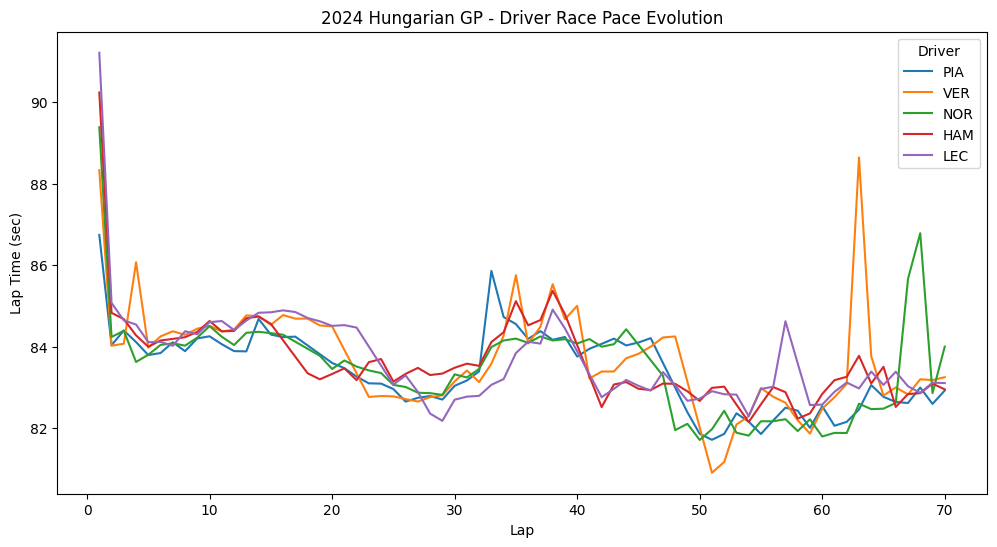

In [92]:
# race pace evolution chart
plt.figure(figsize = (12, 6))
sns.lineplot(
    data = top_5_clean_data,
    x = 'Lap',
    y = 'Lap Time (sec)',
    hue = 'Driver'
)
plt.title('2024 Hungarian GP - Driver Race Pace Evolution')
plt.xlabel('Lap')
plt.ylabel('Lap Time (sec)');

In [93]:
# the graphs seem so messy so use rolling avg
clean_data = clean_data.copy()
clean_data['Rolling Avg'] = (
    clean_data.groupby('Driver')['Lap Time (sec)']
    .transform(lambda x: x.rolling(window = 5, min_periods = 1).mean())
)
clean_data

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec),Rolling Avg
0,PIA,1,1,1:26.746,86.746,NaN,NaN,NaN,86.746000
1,PIA,2,1,1:24.038,84.038,NaN,NaN,NaN,85.392000
2,PIA,3,1,1:24.401,84.401,NaN,NaN,NaN,85.061667
3,PIA,4,1,1:24.115,84.115,NaN,NaN,NaN,84.825000
4,PIA,5,1,1:23.796,83.796,NaN,NaN,NaN,84.619200
...,...,...,...,...,...,...,...,...,...
1348,GAS,27,10,1:26.206,86.206,NaN,NaN,NaN,85.938800
1351,GAS,30,17,1:23.446,83.446,NaN,NaN,NaN,85.489600
1352,GAS,31,16,1:23.340,83.340,NaN,NaN,NaN,84.962800
1353,GAS,32,15,1:23.484,83.484,NaN,NaN,NaN,84.469800


In [94]:
top_5_clean_data = clean_data[clean_data['Driver'].isin(top_5['Driver'])]
top_5_clean_data

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec),Rolling Avg
0,PIA,1,1,1:26.746,86.746,NaN,NaN,NaN,86.746000
1,PIA,2,1,1:24.038,84.038,NaN,NaN,NaN,85.392000
2,PIA,3,1,1:24.401,84.401,NaN,NaN,NaN,85.061667
3,PIA,4,1,1:24.115,84.115,NaN,NaN,NaN,84.825000
4,PIA,5,1,1:23.796,83.796,NaN,NaN,NaN,84.619200
...,...,...,...,...,...,...,...,...,...
345,LEC,66,4,1:23.387,83.387,NaN,NaN,NaN,83.188000
346,LEC,67,4,1:23.030,83.030,NaN,NaN,NaN,83.169600
347,LEC,68,4,1:22.870,82.870,NaN,NaN,NaN,83.148200
348,LEC,69,4,1:23.118,83.118,NaN,NaN,NaN,83.093600


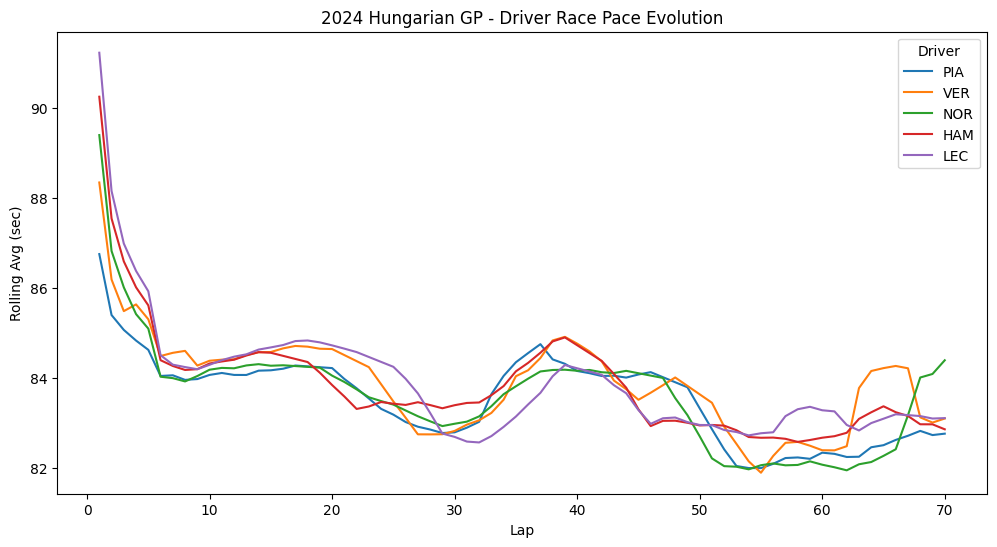

In [95]:
# race pace evolution chart using rolling avg
plt.figure(figsize = (12, 6))
sns.lineplot(
    data = top_5_clean_data,
    x = 'Lap',
    y = 'Rolling Avg',
    hue = 'Driver'
)
plt.title('2024 Hungarian GP - Driver Race Pace Evolution')
plt.xlabel('Lap')
plt.ylabel('Rolling Avg (sec)');

In [96]:
# detect tyre degradation
stints_df

,Driver,TyreCompound,StartLap,EndLap,StintLength
0,PIA,M,1,18,18
1,PIA,H,19,47,29
2,PIA,M,48,70,23
3,NOR,M,1,17,17
4,NOR,H,18,45,28
5,NOR,M,46,70,25
6,HAM,M,1,16,16
7,HAM,H,17,40,24
8,HAM,H,41,70,30
9,LEC,M,1,23,23


In [97]:
# avg pace per stint
avg_stint = []
for _, stint in stints_df.iterrows():
    driver = stint['Driver']
    stint_laps = clean_data[
        (clean_data['Driver'] == driver) &
        (clean_data['Lap'].between(stint['StartLap'], stint['EndLap']))
    ]
    avg_time = stint_laps['Lap Time (sec)'].mean()
    avg_stint.append([
        driver,
        stint['TyreCompound'],
        stint['StartLap'],
        stint['EndLap'],
        stint['StintLength'],
        round(avg_time, 3)
    ])
avg_stint

[['PIA', 'M', 1, 18, 18, np.float64(84.277)],
 ['PIA', 'H', 19, 47, 29, np.float64(83.721)],
 ['PIA', 'M', 48, 70, 23, np.float64(82.372)],
 ['NOR', 'M', 1, 17, 17, np.float64(84.498)],
 ['NOR', 'H', 18, 45, 28, np.float64(83.678)],
 ['NOR', 'M', 46, 70, 25, np.float64(82.623)],
 ['HAM', 'M', 1, 16, 16, np.float64(84.826)],
 ['HAM', 'H', 17, 40, 24, np.float64(83.819)],
 ['HAM', 'H', 41, 70, 30, np.float64(82.902)],
 ['LEC', 'M', 1, 23, 23, np.float64(84.863)],
 ['LEC', 'H', 24, 40, 17, np.float64(83.317)],
 ['LEC', 'M', 41, 70, 30, np.float64(83.031)],
 ['VER', 'M', 1, 21, 21, np.float64(84.721)],
 ['VER', 'H', 22, 49, 28, np.float64(83.709)],
 ['VER', 'M', 50, 70, 21, np.float64(82.896)],
 ['SAI', 'M', 1, 21, 21, np.float64(85.149)],
 ['SAI', 'H', 22, 47, 26, np.float64(83.65)],
 ['SAI', 'M', 48, 70, 23, np.float64(82.61)],
 ['PER', 'H', 1, 28, 28, np.float64(85.897)],
 ['PER', 'M', 29, 47, 19, np.float64(83.141)],
 ['PER', 'M', 48, 70, 23, np.float64(82.408)],
 ['RUS', 'H', 1, 33, 3

In [98]:
avg_stint_pace = pd.DataFrame(
    avg_stint,
    columns = [
        'Driver',
        'TyreCompound',
        'StartLap',
        'EndLap',
        'StintLength',
        'Avg Stint Pace (sec)'
    ]
)
avg_stint_pace = avg_stint_pace.sort_values(by = 'Avg Stint Pace (sec)')
avg_stint_pace

,Driver,TyreCompound,StartLap,EndLap,StintLength,Avg Stint Pace (sec)
50,SAR,S,64,69,6,81.736
23,RUS,H,54,70,17,82.335
2,PIA,M,48,70,23,82.372
20,PER,M,48,70,23,82.408
17,SAI,M,48,70,23,82.610
5,NOR,M,46,70,25,82.623
22,RUS,M,34,53,20,82.762
54,OCO,S,65,69,5,82.821
14,VER,M,50,70,21,82.896
8,HAM,H,41,70,30,82.902


In [99]:
top_5_avg_stint_pace = avg_stint_pace[avg_stint_pace['Driver'].isin(top_5['Driver'])]
top_5_avg_stint_pace

,Driver,TyreCompound,StartLap,EndLap,StintLength,Avg Stint Pace (sec)
2,PIA,M,48,70,23,82.372
5,NOR,M,46,70,25,82.623
14,VER,M,50,70,21,82.896
8,HAM,H,41,70,30,82.902
11,LEC,M,41,70,30,83.031
10,LEC,H,24,40,17,83.317
4,NOR,H,18,45,28,83.678
13,VER,H,22,49,28,83.709
1,PIA,H,19,47,29,83.721
7,HAM,H,17,40,24,83.819


In [100]:
# fastest stint among top 5 finishing drivers
fastest_stint = top_5_avg_stint_pace.loc[
    top_5_avg_stint_pace['Avg Stint Pace (sec)'].idxmin()
]
print(
    f"{fastest_stint['Driver']} has the fastest stint on {tyre[fastest_stint['TyreCompound']]} tyres with a length of {fastest_stint['StintLength']} laps and an average stint pace of {round(fastest_stint['Avg Stint Pace (sec)'], 3)} seconds."
)

PIA has the fastest stint on medium tyres with a length of 23 laps and an average stint pace of 82.372 seconds.


**Insights:**

- PIA maintained the most consistent pace, had the fastest average race pace, and also the fastest stint on medium tyres with a length of 23 laps.
- NOR maintained a nearly identical pace as PIA and also the 2nd fastest stint on medium tyres, confirming McLaren's overall race pace advantage and great tyre management on medium tyres in last stints.
- VER showed competitive pace after swtiching back to medium tyres in the last stint.
- HAM improved as the race progressed and had competitive pace and consistency in the last stint on hard tyres which enabled him to fight for podium.
- LEC was overall slower than others which limited him to fight in the race.

It shows that the pace improved for everyone in later stints most probably due to fuel consumption as it impacts laptimes more than tyre degradation.

In [101]:
# Strategy Outcome Analysis - Race Engineer Report
strategy_summary = result[[
    'Driver', 'No. of stops', 'Pit Loss', 'Pos.'
]]
strategy_summary

,Driver,No. of stops,Pit Loss,Pos.
19,PIA,2,43.464,1
3,NOR,2,43.110,2
15,HAM,2,43.216,3
7,LEC,2,43.617,4
0,VER,2,43.445,5
16,SAI,2,43.094,6
5,PER,2,42.451,7
17,RUS,2,42.697,8
10,TSU,1,21.467,9
8,STR,2,45.513,10


In [102]:
strategy_summary = pd.merge(
    strategy_summary,
    avg_race_pace,
    how = 'left',
    on = 'Driver'
)
strategy_summary

,Driver,No. of stops,Pit Loss,Pos.,Avg Race Pace (sec)
0,PIA,2,43.464,1,83.414818
1,NOR,2,43.110,2,83.493318
2,HAM,2,43.216,3,83.644788
3,LEC,2,43.617,4,83.706652
4,VER,2,43.445,5,83.769167
5,SAI,2,43.094,6,83.757500
6,PER,2,42.451,7,84.023955
7,RUS,2,42.697,8,84.122091
8,TSU,1,21.467,9,84.844221
9,STR,2,45.513,10,84.512848


In [103]:
strategy_summary = strategy_summary.rename(
    columns = {
        'No. of stops': 'Stops',
        'Pit Loss': 'Pit Loss (sec)',
        'Pos.': 'Finish'
    }
)
strategy_summary = strategy_summary.sort_values(by = 'Finish')
strategy_summary

,Driver,Stops,Pit Loss (sec),Finish,Avg Race Pace (sec)
0,PIA,2,43.464,1,83.414818
1,NOR,2,43.110,2,83.493318
2,HAM,2,43.216,3,83.644788
3,LEC,2,43.617,4,83.706652
4,VER,2,43.445,5,83.769167
5,SAI,2,43.094,6,83.757500
6,PER,2,42.451,7,84.023955
7,RUS,2,42.697,8,84.122091
8,TSU,1,21.467,9,84.844221
9,STR,2,45.513,10,84.512848


In [104]:
top_5_strategy_summary = strategy_summary[strategy_summary['Driver'].isin(top_5['Driver'])]
top_5_strategy_summary

,Driver,Stops,Pit Loss (sec),Finish,Avg Race Pace (sec)
0,PIA,2,43.464,1,83.414818
1,NOR,2,43.110,2,83.493318
2,HAM,2,43.216,3,83.644788
3,LEC,2,43.617,4,83.706652
4,VER,2,43.445,5,83.769167


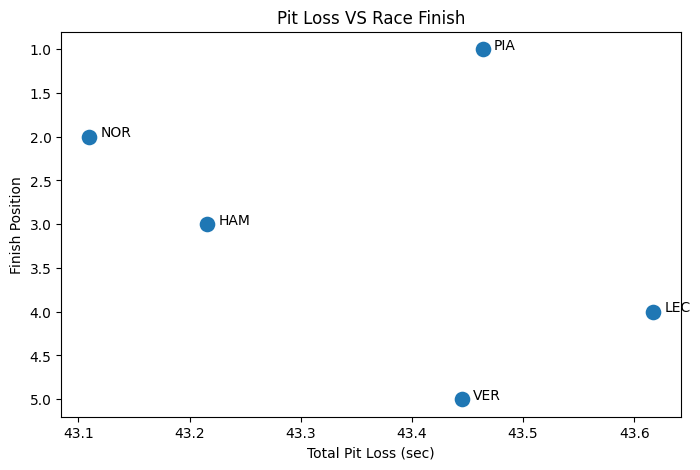

In [105]:
# pit loss vs outcome
plt.figure(figsize = (8, 5))
sns.scatterplot(
    data = top_5_strategy_summary,
    x = 'Pit Loss (sec)',
    y = 'Finish',
    s = 150
)
# driver labels
for _, row in top_5_strategy_summary.iterrows():
    plt.text(
        row['Pit Loss (sec)'] + 0.01,
        row['Finish'],
        row['Driver']
    )
plt.gca().invert_yaxis()
plt.xlabel('Total Pit Loss (sec)')
plt.ylabel('Finish Position')
plt.title('Pit Loss VS Race Finish');

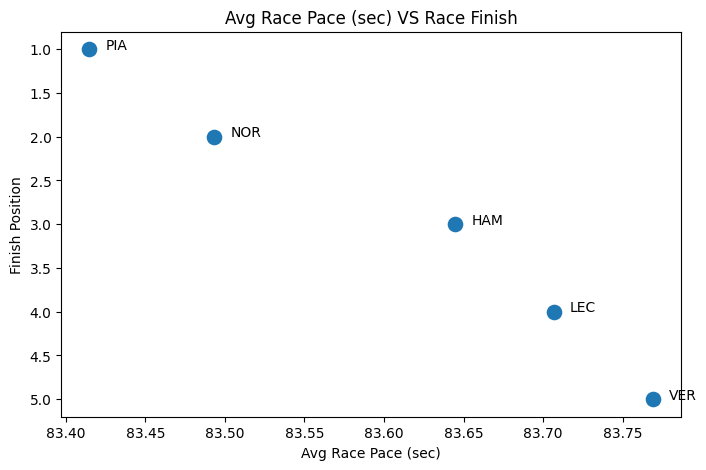

In [106]:
# avg pace vs outcome
plt.figure(figsize = (8, 5))
sns.scatterplot(
    data = top_5_strategy_summary,
    x = 'Avg Race Pace (sec)',
    y = 'Finish',
    s = 150
)
# driver labels
for _, row in top_5_strategy_summary.iterrows():
    plt.text(
        row['Avg Race Pace (sec)'] + 0.01,
        row['Finish'],
        row['Driver']
    )
plt.gca().invert_yaxis()
plt.xlabel('Avg Race Pace (sec)')
plt.ylabel('Finish Position')
plt.title('Avg Race Pace (sec) VS Race Finish');

**Insights:**

- PIA and VER, with similar pit loss but PIA's avg pace was fastest so he finished P1 and VER's avg pace was slowest so he finished P5.
- NOR had the lowest pit-loss but slower in avg pace than PIA so finished P2.
- HAM had lower pit-loss than PIA but was slower in avg pace than PIA and NOR so finished behind both of them, P3.
- LEC had the highest pit-loss but was faster in avg pace than VER so finsihed before VER, P4.

### Final Outcome
- All top 5 finishing drivers executed 2-stop strategy.
- McLaren's M-H-M strategy and highest overall race pace proved highly effective and consistent which got them 1-2 finish.
- Pit-loss differences were very simliar between the top 5 finishing drivers, suggesting that the race pace showed much stronger relation to finishing position than pit-loss.
- While strategy and pit timings affected individual battles, the stronger predictor was the driver's race pace.

In [107]:
# take the csv files for dashboard
top_5_pit = top_5[[
    'Driver', 'Pit 1 Lap', 'Pit 2 Lap', 'Pit 3 Lap', 'No. of stops', 'Pit Loss', 'Pos.'
]]
top_5_pit = top_5_pit.rename(
    columns = {
        'No. of stops': 'Stops',
        'Pos.': 'Finish'
    }
)
top_5_pit

,Driver,Pit 1 Lap,Pit 2 Lap,Pit 3 Lap,Stops,Pit Loss,Finish
0,PIA,18.0,47.0,NaN,2,43.464,1
1,NOR,17.0,45.0,NaN,2,43.110,2
2,HAM,16.0,40.0,NaN,2,43.216,3
3,LEC,23.0,40.0,NaN,2,43.617,4
4,VER,21.0,49.0,NaN,2,43.445,5


In [108]:
top_5_pit.to_csv('data/top_5_pit_timeline.csv', index = False)

In [109]:
top_5_tyre

,Driver,TyreCompound,StartLap,EndLap,StintLength
0,PIA,M,1,18,18
1,PIA,H,19,47,29
2,PIA,M,48,70,23
3,NOR,M,1,17,17
4,NOR,H,18,45,28
5,NOR,M,46,70,25
6,HAM,M,1,16,16
7,HAM,H,17,40,24
8,HAM,H,41,70,30
9,LEC,M,1,23,23


In [110]:
top_5_tyre.to_csv('data/top_5_tyre_stints.csv', index = False)

In [111]:
top_5_clean_data

,Driver,Lap,Position,Lap Time,Lap Time (sec),Stops,Pit Time (sec),Total Pit Time (sec),Rolling Avg
0,PIA,1,1,1:26.746,86.746,NaN,NaN,NaN,86.746000
1,PIA,2,1,1:24.038,84.038,NaN,NaN,NaN,85.392000
2,PIA,3,1,1:24.401,84.401,NaN,NaN,NaN,85.061667
3,PIA,4,1,1:24.115,84.115,NaN,NaN,NaN,84.825000
4,PIA,5,1,1:23.796,83.796,NaN,NaN,NaN,84.619200
...,...,...,...,...,...,...,...,...,...
345,LEC,66,4,1:23.387,83.387,NaN,NaN,NaN,83.188000
346,LEC,67,4,1:23.030,83.030,NaN,NaN,NaN,83.169600
347,LEC,68,4,1:22.870,82.870,NaN,NaN,NaN,83.148200
348,LEC,69,4,1:23.118,83.118,NaN,NaN,NaN,83.093600


In [112]:
top_5_clean_data.to_csv('data/top_5_race_pace.csv', index = False)

In [113]:
top_5_strategy_summary

,Driver,Stops,Pit Loss (sec),Finish,Avg Race Pace (sec)
0,PIA,2,43.464,1,83.414818
1,NOR,2,43.110,2,83.493318
2,HAM,2,43.216,3,83.644788
3,LEC,2,43.617,4,83.706652
4,VER,2,43.445,5,83.769167


In [114]:
top_5_strategy_summary.to_csv('data/top_5_strategy_summary.csv', index = False)